# EVChargeIQ — Business KPIs

## Public EV Charging Demand, Revenue & Infrastructure Analytics

### Objective

This notebook converts the engineered EV charging transaction data into business-oriented KPIs.

The analysis focuses on:

- Charging demand
- Time-based utilization patterns
- AC vs DC charging behavior
- Revenue and pricing
- Station performance
- Infrastructure capacity

### Input Data

- `transactions_2025-01_processed.parquet`
- `transactions_2025-07_processed.parquet`
- `stations_public.parquet`

### Output

Business KPI tables that will later support:

- Dashboard development
- Business recommendations
- Station performance analysis
- Executive-level insights

In [ ]:
import os
import pandas as pd
import numpy as np
import pyarrow as pa
import pyarrow.parquet as pq

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
BASE_PATH = "/content/EVChargeIQ_data"
PROCESSED_PATH = "/content/EVChargeIQ_processed"

jan_processed_path = (
    f"{PROCESSED_PATH}/"
    "transactions_2025-01_processed.parquet"
)

jul_processed_path = (
    f"{PROCESSED_PATH}/"
    "transactions_2025-07_processed.parquet"
)

stations_path = (
    f"{BASE_PATH}/"
    "stations_public.parquet"
)

print("Paths configured.")

Paths configured.


In [ ]:
import os

os.makedirs("/content/EVChargeIQ_data", exist_ok=True)
os.makedirs("/content/EVChargeIQ_processed", exist_ok=True)

print("Folders created.")

Folders created.


In [ ]:
import os

print("Files directly inside /content:\n")

for item in os.listdir("/content"):
    print(item)

Files directly inside /content:

.config
EVChargeIQ_processed
EVChargeIQ_data
EVChargeIQ_dashboard
sample_data


In [ ]:
print("\nFiles inside EVChargeIQ_data:")
print(os.listdir("/content/EVChargeIQ_data"))

print("\nFiles inside EVChargeIQ_processed:")
print(os.listdir("/content/EVChargeIQ_processed"))


Files inside EVChargeIQ_data:
[]

Files inside EVChargeIQ_processed:
[]


In [ ]:
import os

print("Searching for Parquet files...\n")

found_files = []

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith(".parquet"):
            path = os.path.join(root, file)
            found_files.append(path)
            print(path)

print("\nTotal Parquet files found:", len(found_files))

Searching for Parquet files...


Total Parquet files found: 0


In [ ]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving transactions_2025-07_processed.parquet to transactions_2025-07_processed.parquet
Saving stations_public.parquet to stations_public.parquet
Saving transactions_2025-01_processed.parquet to transactions_2025-01_processed.parquet

Uploaded files:
transactions_2025-07_processed.parquet
stations_public.parquet
transactions_2025-01_processed.parquet


In [ ]:
import shutil
import os

shutil.move(
    "/content/stations_public.parquet",
    "/content/EVChargeIQ_data/stations_public.parquet"
)

shutil.move(
    "/content/transactions_2025-01_processed.parquet",
    "/content/EVChargeIQ_processed/transactions_2025-01_processed.parquet"
)

shutil.move(
    "/content/transactions_2025-07_processed.parquet",
    "/content/EVChargeIQ_processed/transactions_2025-07_processed.parquet"
)

print("All files moved successfully.")

All files moved successfully.


In [ ]:
print("EVChargeIQ_data:")
print(os.listdir("/content/EVChargeIQ_data"))

print("\nEVChargeIQ_processed:")
print(os.listdir("/content/EVChargeIQ_processed"))

EVChargeIQ_data:
[]

EVChargeIQ_processed:
[]


In [ ]:
required_files = [
    stations_path,
    jan_processed_path,
    jul_processed_path
]

for file_path in required_files:
    print(
        os.path.basename(file_path),
        "→",
        "FOUND" if os.path.exists(file_path) else "NOT FOUND"
    )

stations_public.parquet → NOT FOUND
transactions_2025-01_processed.parquet → NOT FOUND
transactions_2025-07_processed.parquet → NOT FOUND


In [ ]:
jan_file = pq.ParquetFile(jan_processed_path)
jul_file = pq.ParquetFile(jul_processed_path)

jan_rows = jan_file.metadata.num_rows
jul_rows = jul_file.metadata.num_rows

print("January rows:", jan_rows)
print("July rows:", jul_rows)
print("Total transactions:", jan_rows + jul_rows)

January rows: 2137234
July rows: 6407461
Total transactions: 8544695


In [ ]:
kpi_columns = [
    "total_elec_kwh",
    "total_elec_fee",
    "total_service_fee",
    "total_fee",
    "duration_min"
]

print("KPI columns configured:")
print(kpi_columns)

KPI columns configured:
['total_elec_kwh', 'total_elec_fee', 'total_service_fee', 'total_fee', 'duration_min']


In [ ]:
jan_kpi_data = pd.read_parquet(
    jan_processed_path,
    columns=kpi_columns
)

print("January KPI data shape:", jan_kpi_data.shape)

January KPI data shape: (2137234, 5)


In [ ]:
jul_kpi_data = pd.read_parquet(
    jul_processed_path,
    columns=kpi_columns
)

print("July KPI data shape:", jul_kpi_data.shape)

July KPI data shape: (6407461, 5)


In [ ]:
def calculate_overall_kpis(df):
    return {
        "transactions": len(df),
        "total_energy_kwh": df["total_elec_kwh"].sum(),
        "total_electricity_fee": df["total_elec_fee"].sum(),
        "total_service_fee": df["total_service_fee"].sum(),
        "total_revenue": df["total_fee"].sum(),
        "average_session_duration_min": df["duration_min"].mean(),
        "average_energy_per_session_kwh": df["total_elec_kwh"].mean(),
        "average_revenue_per_session": df["total_fee"].mean()
    }

print("KPI calculation function created.")

KPI calculation function created.


In [ ]:
jan_kpis = calculate_overall_kpis(jan_kpi_data)
jul_kpis = calculate_overall_kpis(jul_kpi_data)

print("January KPIs:")
for key, value in jan_kpis.items():
    if isinstance(value, (float, np.floating)):
        print(f"{key}: {value:,.2f}")
    else:
        print(f"{key}: {value:,}")

print("\nJuly KPIs:")
for key, value in jul_kpis.items():
    if isinstance(value, (float, np.floating)):
        print(f"{key}: {value:,.2f}")
    else:
        print(f"{key}: {value:,}")

January KPIs:
transactions: 2,137,234
total_energy_kwh: 61,897,492.42
total_electricity_fee: 43,036,417.42
total_service_fee: 30,346,232.21
total_revenue: 73,382,649.63
average_session_duration_min: 67.90
average_energy_per_session_kwh: 28.96
average_revenue_per_session: 34.34

July KPIs:
transactions: 6,407,461
total_energy_kwh: 175,974,584.04
total_electricity_fee: 124,385,992.98
total_service_fee: 67,667,855.87
total_revenue: 192,053,848.86
average_session_duration_min: 57.79
average_energy_per_session_kwh: 27.46
average_revenue_per_session: 29.97


In [ ]:
overall_kpis = pd.DataFrame(
    [jan_kpis, jul_kpis],
    index=["January 2025", "July 2025"]
)

overall_kpis

,transactions,total_energy_kwh,total_electricity_fee,total_service_fee,total_revenue,average_session_duration_min,average_energy_per_session_kwh,average_revenue_per_session
January 2025,2137234,6.189749e+07,4.303642e+07,3.034623e+07,7.338265e+07,67.898350,28.961495,34.335337
July 2025,6407461,1.759746e+08,1.243860e+08,6.766786e+07,1.920538e+08,57.791308,27.464012,29.973471


In [ ]:
comparison = pd.DataFrame({
    "January": overall_kpis.loc["January 2025"],
    "July": overall_kpis.loc["July 2025"]
})

comparison["absolute_change"] = (
    comparison["July"] -
    comparison["January"]
)

comparison["percentage_change"] = (
    comparison["absolute_change"] /
    comparison["January"].replace(0, np.nan)
) * 100

comparison

,January,July,absolute_change,percentage_change
transactions,2.137234e+06,6.407461e+06,4.270227e+06,199.801566
total_energy_kwh,6.189749e+07,1.759746e+08,1.140771e+08,184.300021
total_electricity_fee,4.303642e+07,1.243860e+08,8.134958e+07,189.024971
total_service_fee,3.034623e+07,6.766786e+07,3.732162e+07,122.986021
total_revenue,7.338265e+07,1.920538e+08,1.186712e+08,161.715610
average_session_duration_min,6.789835e+01,5.779131e+01,-1.010704e+01,-14.885548
average_energy_per_session_kwh,2.896150e+01,2.746401e+01,-1.497484e+00,-5.170602
average_revenue_per_session,3.433534e+01,2.997347e+01,-4.361866e+00,-12.703722


In [ ]:
print("January → July percentage changes:")

print(
    comparison["percentage_change"]
    .sort_values(ascending=False)
)

January → July percentage changes:
transactions                      199.801566
total_electricity_fee             189.024971
total_energy_kwh                  184.300021
total_revenue                     161.715610
total_service_fee                 122.986021
average_energy_per_session_kwh     -5.170602
average_revenue_per_session       -12.703722
average_session_duration_min      -14.885548
Name: percentage_change, dtype: float64


In [ ]:
hour_columns = [
    "charge_hour",
    "total_elec_kwh",
    "total_fee"
]

jan_hourly_data = pd.read_parquet(
    jan_processed_path,
    columns=hour_columns
)

jul_hourly_data = pd.read_parquet(
    jul_processed_path,
    columns=hour_columns
)

print("January hourly data:", jan_hourly_data.shape)
print("July hourly data:", jul_hourly_data.shape)

January hourly data: (2137234, 3)
July hourly data: (6407461, 3)


In [ ]:
jan_hourly = (
    jan_hourly_data
    .groupby("charge_hour")
    .agg(
        transactions=("charge_hour", "size"),
        total_energy_kwh=("total_elec_kwh", "sum"),
        total_revenue=("total_fee", "sum")
    )
    .reset_index()
)

jul_hourly = (
    jul_hourly_data
    .groupby("charge_hour")
    .agg(
        transactions=("charge_hour", "size"),
        total_energy_kwh=("total_elec_kwh", "sum"),
        total_revenue=("total_fee", "sum")
    )
    .reset_index()
)

print("January hourly summary:")
print(jan_hourly)

print("\nJuly hourly summary:")
print(jul_hourly)

January hourly summary:
    charge_hour  transactions  total_energy_kwh  total_revenue
0             0        122691      3.995613e+06     3416910.38
1             1         80557      2.948134e+06     2221943.94
2             2         53627      1.730410e+06     1458518.67
3             3         31138      1.041713e+06      802320.84
4             4         26148      8.276547e+05      648294.63
5             5         32224      1.125685e+06      765033.78
6             6         24021      6.665063e+05      557485.69
7             7         14231      4.754295e+05      538308.03
8             8         16220      5.312343e+05      822340.31
9             9         13152      4.208326e+05      748960.88
10           10         15944      5.115609e+05      918575.13
11           11         45194      1.344598e+06     2119405.57
12           12         90605      2.472450e+06     3506194.64
13           13        131523      3.556693e+06     4453668.47
14           14        138331  

In [ ]:
jan_peak_hour = jan_hourly.loc[
    jan_hourly["transactions"].idxmax()
]

jul_peak_hour = jul_hourly.loc[
    jul_hourly["transactions"].idxmax()
]

print("January peak hour:")
print(jan_peak_hour)

print("\nJuly peak hour:")
print(jul_peak_hour)

January peak hour:
charge_hour         2.300000e+01
transactions        1.983170e+05
total_energy_kwh    6.674238e+06
total_revenue       5.777764e+06
Name: 23, dtype: float64

July peak hour:
charge_hour         2.300000e+01
transactions        4.680370e+05
total_energy_kwh    1.583841e+07
total_revenue       1.250286e+07
Name: 23, dtype: float64


In [ ]:
hourly_comparison = jan_hourly.merge(
    jul_hourly,
    on="charge_hour",
    how="outer",
    suffixes=("_january", "_july")
)

hourly_comparison["transaction_change_pct"] = (
    (
        hourly_comparison["transactions_july"] -
        hourly_comparison["transactions_january"]
    )
    /
    hourly_comparison["transactions_january"]
    .replace(0, np.nan)
) * 100

hourly_comparison

,charge_hour,transactions_january,total_energy_kwh_january,total_revenue_january,transactions_july,total_energy_kwh_july,total_revenue_july,transaction_change_pct
0,0,122691,3.995613e+06,3416910.38,297912,9.382247e+06,7.199287e+06,142.814876
1,1,80557,2.948134e+06,2221943.94,196135,6.239677e+06,4.727319e+06,143.473565
2,2,53627,1.730410e+06,1458518.67,130572,4.292305e+06,3.203056e+06,143.481828
3,3,31138,1.041713e+06,802320.84,106878,3.631444e+06,2.707233e+06,243.239771
4,4,26148,8.276547e+05,648294.63,124996,3.971549e+06,2.989079e+06,378.032737
5,5,32224,1.125685e+06,765033.78,263033,7.831987e+06,5.915983e+06,716.264275
6,6,24021,6.665063e+05,557485.69,279991,7.381307e+06,6.215078e+06,1065.609259
7,7,14231,4.754295e+05,538308.03,195036,5.158679e+06,5.829411e+06,1270.501019
8,8,16220,5.312343e+05,822340.31,250334,7.227496e+06,8.463884e+06,1443.366215
9,9,13152,4.208326e+05,748960.88,229579,6.131689e+06,7.580983e+06,1645.582421


In [ ]:
day_columns = [
    "is_weekend",
    "total_elec_kwh",
    "total_fee",
    "duration_min"
]

jan_day_data = pd.read_parquet(
    jan_processed_path,
    columns=day_columns
)

jul_day_data = pd.read_parquet(
    jul_processed_path,
    columns=day_columns
)

print("January:", jan_day_data.shape)
print("July:", jul_day_data.shape)

January: (2137234, 4)
July: (6407461, 4)


In [ ]:
jan_day_summary = (
    jan_day_data
    .groupby("is_weekend")
    .agg(
        transactions=("is_weekend", "size"),
        total_energy_kwh=("total_elec_kwh", "sum"),
        total_revenue=("total_fee", "sum"),
        avg_duration_min=("duration_min", "mean")
    )
    .reset_index()
)

jul_day_summary = (
    jul_day_data
    .groupby("is_weekend")
    .agg(
        transactions=("is_weekend", "size"),
        total_energy_kwh=("total_elec_kwh", "sum"),
        total_revenue=("total_fee", "sum"),
        avg_duration_min=("duration_min", "mean")
    )
    .reset_index()
)

print("January weekday/weekend:")
print(jan_day_summary)

print("\nJuly weekday/weekend:")
print(jul_day_summary)

January weekday/weekend:
   is_weekend  transactions  total_energy_kwh  total_revenue  avg_duration_min
0       False       1572544      4.503947e+07    54243565.50         68.851832
1        True        564690      1.685802e+07    19139084.13         65.243101

July weekday/weekend:
   is_weekend  transactions  total_energy_kwh  total_revenue  avg_duration_min
0       False       4805104      1.313642e+08   1.434626e+08         58.427244
1        True       1602357      4.461037e+07   4.859127e+07         55.884281


In [ ]:
for summary in [jan_day_summary, jul_day_summary]:

    summary["transaction_share_pct"] = (
        summary["transactions"] /
        summary["transactions"].sum()
    ) * 100

    summary["energy_share_pct"] = (
        summary["total_energy_kwh"] /
        summary["total_energy_kwh"].sum()
    ) * 100

    summary["revenue_share_pct"] = (
        summary["total_revenue"] /
        summary["total_revenue"].sum()
    ) * 100


print("January:")
print(jan_day_summary)

print("\nJuly:")
print(jul_day_summary)

January:
   is_weekend  transactions  total_energy_kwh  total_revenue  \
0       False       1572544      4.503947e+07    54243565.50   
1        True        564690      1.685802e+07    19139084.13   

   avg_duration_min  transaction_share_pct  energy_share_pct  \
0         68.851832              73.578466         72.764611   
1         65.243101              26.421534         27.235389   

   revenue_share_pct  
0          73.918788  
1          26.081212  

July:
   is_weekend  transactions  total_energy_kwh  total_revenue  \
0       False       4805104      1.313642e+08   1.434626e+08   
1        True       1602357      4.461037e+07   4.859127e+07   

   avg_duration_min  transaction_share_pct  energy_share_pct  \
0         58.427244              74.992325         74.649539   
1         55.884281              25.007675         25.350461   

   revenue_share_pct  
0          74.699143  
1          25.300857  


In [ ]:
def label_weekend(value):
    return "Weekend" if value else "Weekday"


jan_day_summary["day_type"] = (
    jan_day_summary["is_weekend"]
    .apply(label_weekend)
)

jul_day_summary["day_type"] = (
    jul_day_summary["is_weekend"]
    .apply(label_weekend)
)

print("January:")
print(
    jan_day_summary[
        [
            "day_type",
            "transactions",
            "transaction_share_pct",
            "total_energy_kwh",
            "energy_share_pct",
            "total_revenue",
            "revenue_share_pct",
            "avg_duration_min"
        ]
    ]
)

print("\nJuly:")
print(
    jul_day_summary[
        [
            "day_type",
            "transactions",
            "transaction_share_pct",
            "total_energy_kwh",
            "energy_share_pct",
            "total_revenue",
            "revenue_share_pct",
            "avg_duration_min"
        ]
    ]
)

January:
  day_type  transactions  transaction_share_pct  total_energy_kwh  \
0  Weekday       1572544              73.578466      4.503947e+07   
1  Weekend        564690              26.421534      1.685802e+07   

   energy_share_pct  total_revenue  revenue_share_pct  avg_duration_min  
0         72.764611    54243565.50          73.918788         68.851832  
1         27.235389    19139084.13          26.081212         65.243101  

July:
  day_type  transactions  transaction_share_pct  total_energy_kwh  \
0  Weekday       4805104              74.992325      1.313642e+08   
1  Weekend       1602357              25.007675      4.461037e+07   

   energy_share_pct  total_revenue  revenue_share_pct  avg_duration_min  
0         74.649539   1.434626e+08          74.699143         58.427244  
1         25.350461   4.859127e+07          25.300857         55.884281  


In [ ]:
equipment_columns = [
    "equipment_type",
    "total_elec_kwh",
    "total_fee",
    "duration_min"
]

jan_equipment_data = pd.read_parquet(
    jan_processed_path,
    columns=equipment_columns
)

jul_equipment_data = pd.read_parquet(
    jul_processed_path,
    columns=equipment_columns
)

print("January:", jan_equipment_data.shape)
print("July:", jul_equipment_data.shape)

January: (2137234, 4)
July: (6407461, 4)


In [ ]:
jan_equipment_summary = (
    jan_equipment_data
    .groupby("equipment_type")
    .agg(
        transactions=("equipment_type", "size"),
        total_energy_kwh=("total_elec_kwh", "sum"),
        total_revenue=("total_fee", "sum"),
        avg_duration_min=("duration_min", "mean"),
        avg_energy_per_session_kwh=("total_elec_kwh", "mean"),
        avg_revenue_per_session=("total_fee", "mean")
    )
    .reset_index()
)

jul_equipment_summary = (
    jul_equipment_data
    .groupby("equipment_type")
    .agg(
        transactions=("equipment_type", "size"),
        total_energy_kwh=("total_elec_kwh", "sum"),
        total_revenue=("total_fee", "sum"),
        avg_duration_min=("duration_min", "mean"),
        avg_energy_per_session_kwh=("total_elec_kwh", "mean"),
        avg_revenue_per_session=("total_fee", "mean")
    )
    .reset_index()
)

print("January AC/DC summary:")
print(jan_equipment_summary)

print("\nJuly AC/DC summary:")
print(jul_equipment_summary)

January AC/DC summary:
      equipment_type  transactions  total_energy_kwh  total_revenue  \
0       AC Equipment        197225      4.576156e+06     5610995.80   
1       DC Equipment       1938830      5.728760e+07    67735588.50   
2  Unknown / Missing          1179      3.373989e+04       36065.33   

   avg_duration_min  avg_energy_per_session_kwh  avg_revenue_per_session  
0        258.406997                   23.202720                28.449719  
1         48.523156                   29.547509                34.936322  
2         61.230817                   28.617377                30.589763  

July AC/DC summary:
  equipment_type  transactions  total_energy_kwh  total_revenue  \
0   AC Equipment        518163      1.196660e+07   1.458713e+07   
1   DC Equipment       5889298      1.640080e+08   1.774667e+08   

   avg_duration_min  avg_energy_per_session_kwh  avg_revenue_per_session  
0        258.228970                   23.094279                28.151629  
1         40.156035

In [ ]:
for summary in [
    jan_equipment_summary,
    jul_equipment_summary
]:

    summary["transaction_share_pct"] = (
        summary["transactions"] /
        summary["transactions"].sum()
    ) * 100

    summary["energy_share_pct"] = (
        summary["total_energy_kwh"] /
        summary["total_energy_kwh"].sum()
    ) * 100

    summary["revenue_share_pct"] = (
        summary["total_revenue"] /
        summary["total_revenue"].sum()
    ) * 100

In [ ]:
print("JANUARY")
print(
    jan_equipment_summary[
        [
            "equipment_type",
            "transactions",
            "transaction_share_pct",
            "total_energy_kwh",
            "energy_share_pct",
            "total_revenue",
            "revenue_share_pct",
            "avg_duration_min",
            "avg_energy_per_session_kwh",
            "avg_revenue_per_session"
        ]
    ]
)

print("\nJULY")
print(
    jul_equipment_summary[
        [
            "equipment_type",
            "transactions",
            "transaction_share_pct",
            "total_energy_kwh",
            "energy_share_pct",
            "total_revenue",
            "revenue_share_pct",
            "avg_duration_min",
            "avg_energy_per_session_kwh",
            "avg_revenue_per_session"
        ]
    ]
)

JANUARY
      equipment_type  transactions  transaction_share_pct  total_energy_kwh  \
0       AC Equipment        197225               9.228049      4.576156e+06   
1       DC Equipment       1938830              90.716786      5.728760e+07   
2  Unknown / Missing          1179               0.055165      3.373989e+04   

   energy_share_pct  total_revenue  revenue_share_pct  avg_duration_min  \
0          7.393121     5610995.80           7.646216        258.406997   
1         92.552370    67735588.50          92.304637         48.523156   
2          0.054509       36065.33           0.049147         61.230817   

   avg_energy_per_session_kwh  avg_revenue_per_session  
0                   23.202720                28.449719  
1                   29.547509                34.936322  
2                   28.617377                30.589763  

JULY
  equipment_type  transactions  transaction_share_pct  total_energy_kwh  \
0   AC Equipment        518163               8.086869      1.1966

In [ ]:
station_columns = [
    "station_id",
    "total_elec_kwh",
    "total_fee",
    "duration_min",
    "equipment_type",
    "piles_num",
    "charging_gun_num",
    "station_total_power_kw",
    "construction_site"
]

jan_station_data = pd.read_parquet(
    jan_processed_path,
    columns=station_columns
)

jul_station_data = pd.read_parquet(
    jul_processed_path,
    columns=station_columns
)

print("January:", jan_station_data.shape)
print("July:", jul_station_data.shape)

January: (2137234, 9)
July: (6407461, 9)


In [ ]:
def create_station_kpis(df):

    station_kpis = (
        df.groupby("station_id")
        .agg(
            transactions=("station_id", "size"),
            total_energy_kwh=("total_elec_kwh", "sum"),
            total_revenue=("total_fee", "sum"),
            avg_duration_min=("duration_min", "mean"),
            station_power_kw=("station_total_power_kw", "first"),
            piles_num=("piles_num", "first"),
            charging_gun_num=("charging_gun_num", "first"),
            construction_site=("construction_site", "first")
        )
        .reset_index()
    )

    station_kpis["revenue_per_transaction"] = (
        station_kpis["total_revenue"] /
        station_kpis["transactions"]
    )

    station_kpis["energy_per_transaction_kwh"] = (
        station_kpis["total_energy_kwh"] /
        station_kpis["transactions"]
    )

    return station_kpis


jan_station_kpis = create_station_kpis(jan_station_data)
jul_station_kpis = create_station_kpis(jul_station_data)

print("January stations:", len(jan_station_kpis))
print("July stations:", len(jul_station_kpis))

January stations: 6246
July stations: 7972


In [ ]:
print("TOP 10 — JANUARY BY TRANSACTIONS")

print(
    jan_station_kpis
    .nlargest(10, "transactions")[
        [
            "station_id",
            "transactions",
            "total_energy_kwh",
            "total_revenue",
            "piles_num",
            "charging_gun_num",
            "construction_site"
        ]
    ]
)

print("\nTOP 10 — JULY BY TRANSACTIONS")

print(
    jul_station_kpis
    .nlargest(10, "transactions")[
        [
            "station_id",
            "transactions",
            "total_energy_kwh",
            "total_revenue",
            "piles_num",
            "charging_gun_num",
            "construction_site"
        ]
    ]
)

TOP 10 — JANUARY BY TRANSACTIONS
     station_id  transactions  total_energy_kwh  total_revenue  piles_num  \
4073  ST_005238         23369        482378.024      705497.60      106.0   
1305  ST_001611         15186        360924.910      506789.31       29.0   
4724  ST_006028         13912        336306.540      318652.25       42.0   
1904  ST_002276         11168        189642.990      282039.50       50.0   
5009  ST_006360         11146        244016.400      251445.67       40.0   
4903  ST_006237          9228        279266.700      245964.71       40.0   
6245  ST_008533          8528        223620.450      284331.48       30.0   
3751  ST_004847          7932        186364.970      190797.50        6.0   
4739  ST_006049          7626        238572.110      190655.43        5.0   
3038  ST_003567          7266        319510.872      312487.95       25.0   

      charging_gun_num construction_site  
4073             116.0              公共机构  
1305              56.0           

In [ ]:
def add_station_intensity_metrics(station_kpis):

    station_kpis = station_kpis.copy()

    station_kpis["transactions_per_pile"] = np.where(
        station_kpis["piles_num"] > 0,
        station_kpis["transactions"] /
        station_kpis["piles_num"],
        np.nan
    )

    station_kpis["transactions_per_gun"] = np.where(
        station_kpis["charging_gun_num"] > 0,
        station_kpis["transactions"] /
        station_kpis["charging_gun_num"],
        np.nan
    )

    station_kpis["energy_per_pile_kwh"] = np.where(
        station_kpis["piles_num"] > 0,
        station_kpis["total_energy_kwh"] /
        station_kpis["piles_num"],
        np.nan
    )

    station_kpis["revenue_per_pile"] = np.where(
        station_kpis["piles_num"] > 0,
        station_kpis["total_revenue"] /
        station_kpis["piles_num"],
        np.nan
    )

    return station_kpis


jan_station_kpis = add_station_intensity_metrics(
    jan_station_kpis
)

jul_station_kpis = add_station_intensity_metrics(
    jul_station_kpis
)

print("Station intensity metrics created.")

Station intensity metrics created.


In [ ]:
print("TOP 10 JANUARY — TRANSACTIONS PER PILE")

print(
    jan_station_kpis
    .nlargest(10, "transactions_per_pile")[
        [
            "station_id",
            "transactions",
            "piles_num",
            "charging_gun_num",
            "transactions_per_pile",
            "total_energy_kwh",
            "total_revenue",
            "construction_site"
        ]
    ]
)

TOP 10 JANUARY — TRANSACTIONS PER PILE
     station_id  transactions  piles_num  charging_gun_num  \
6035  ST_007920          6410        2.0              28.0   
6043  ST_007928          3065        1.0              12.0   
3777  ST_004885          3638        2.0              40.0   
6150  ST_008255          1694        1.0              10.0   
3661  ST_004709          1638        1.0              16.0   
3896  ST_005032          1554        1.0              10.0   
5036  ST_006393          1545        1.0              10.0   
4739  ST_006049          7626        5.0              62.0   
5007  ST_006358          1525        1.0              14.0   
4904  ST_006238          2990        2.0              24.0   

      transactions_per_pile  total_energy_kwh  total_revenue construction_site  
6035                 3205.0        207256.560      183418.88                其他  
6043                 3065.0         57820.640       78796.93                其他  
3777                 1819.0        

In [ ]:
print("\nTOP 10 JULY — TRANSACTIONS PER PILE")

print(
    jul_station_kpis
    .nlargest(10, "transactions_per_pile")[
        [
            "station_id",
            "transactions",
            "piles_num",
            "charging_gun_num",
            "transactions_per_pile",
            "total_energy_kwh",
            "total_revenue",
            "construction_site"
        ]
    ]
)


TOP 10 JULY — TRANSACTIONS PER PILE
     station_id  transactions  piles_num  charging_gun_num  \
6626  ST_007139          9425        1.0              24.0   
6601  ST_007113          7712        1.0              18.0   
6404  ST_006905          7226        1.0              12.0   
6278  ST_006766          6561        1.0              24.0   
3895  ST_004234          6134        1.0              20.0   
3896  ST_004235          6012        1.0              10.0   
4496  ST_004885         11805        2.0              40.0   
4326  ST_004709          5834        1.0              16.0   
5362  ST_005786          5781        1.0              16.0   
5897  ST_006358          5684        1.0              14.0   

      transactions_per_pile  total_energy_kwh  total_revenue construction_site  
6626                 9425.0         277239.13      254523.89                其他  
6601                 7712.0         215593.46      181101.45                其他  
6404                 7226.0         1

In [ ]:
print("TOP 10 JANUARY — REVENUE PER PILE")

print(
    jan_station_kpis
    .nlargest(10, "revenue_per_pile")[
        [
            "station_id",
            "transactions",
            "piles_num",
            "revenue_per_pile",
            "transactions_per_pile",
            "total_revenue",
            "construction_site"
        ]
    ]
)

print("\nTOP 10 JULY — REVENUE PER PILE")

print(
    jul_station_kpis
    .nlargest(10, "revenue_per_pile")[
        [
            "station_id",
            "transactions",
            "piles_num",
            "revenue_per_pile",
            "transactions_per_pile",
            "total_revenue",
            "construction_site"
        ]
    ]
)

TOP 10 JANUARY — REVENUE PER PILE
     station_id  transactions  piles_num  revenue_per_pile  \
6035  ST_007920          6410        2.0      91709.440000   
6043  ST_007928          3065        1.0      78796.930000   
3090  ST_003698          1603        2.0      70707.315000   
4706  ST_006005           926        1.0      70413.720000   
4819  ST_006142           776        1.0      63801.300000   
4879  ST_006208           699        1.0      60963.110000   
4861  ST_006187           702        1.0      58905.420000   
5091  ST_006457           731        1.0      58227.300000   
2968  ST_003476          1955        3.0      57462.433333   
4476  ST_005754          1323        2.0      54833.470000   

      transactions_per_pile  total_revenue construction_site  
6035            3205.000000      183418.88                其他  
6043            3065.000000       78796.93                其他  
3090             801.500000      141414.63         大型建筑配建停车场  
4706             926.000000    

In [ ]:
jan_correlations = jan_station_kpis[
    [
        "transactions",
        "piles_num",
        "charging_gun_num",
        "station_power_kw",
        "total_energy_kwh",
        "total_revenue"
    ]
].corr()["transactions"].sort_values(ascending=False)

jul_correlations = jul_station_kpis[
    [
        "transactions",
        "piles_num",
        "charging_gun_num",
        "station_power_kw",
        "total_energy_kwh",
        "total_revenue"
    ]
].corr()["transactions"].sort_values(ascending=False)

print("January correlations with transaction volume:")
print(jan_correlations)

print("\nJuly correlations with transaction volume:")
print(jul_correlations)

January correlations with transaction volume:
transactions        1.000000
total_revenue       0.912251
total_energy_kwh    0.835809
station_power_kw    0.561773
charging_gun_num    0.367452
piles_num           0.195633
Name: transactions, dtype: float64

July correlations with transaction volume:
transactions        1.000000
total_energy_kwh    0.945831
total_revenue       0.923257
station_power_kw    0.594407
charging_gun_num    0.370522
piles_num           0.139483
Name: transactions, dtype: float64


In [ ]:
def add_capacity_metrics(station_kpis):

    station_kpis = station_kpis.copy()

    station_kpis["transactions_per_gun"] = np.where(
        station_kpis["charging_gun_num"] > 0,
        station_kpis["transactions"] /
        station_kpis["charging_gun_num"],
        np.nan
    )

    station_kpis["energy_per_gun_kwh"] = np.where(
        station_kpis["charging_gun_num"] > 0,
        station_kpis["total_energy_kwh"] /
        station_kpis["charging_gun_num"],
        np.nan
    )

    station_kpis["revenue_per_gun"] = np.where(
        station_kpis["charging_gun_num"] > 0,
        station_kpis["total_revenue"] /
        station_kpis["charging_gun_num"],
        np.nan
    )

    station_kpis["transactions_per_mw"] = np.where(
        station_kpis["station_power_kw"] > 0,
        station_kpis["transactions"] /
        (station_kpis["station_power_kw"] / 1000),
        np.nan
    )

    station_kpis["energy_per_mw_kwh"] = np.where(
        station_kpis["station_power_kw"] > 0,
        station_kpis["total_energy_kwh"] /
        (station_kpis["station_power_kw"] / 1000),
        np.nan
    )

    station_kpis["revenue_per_mw"] = np.where(
        station_kpis["station_power_kw"] > 0,
        station_kpis["total_revenue"] /
        (station_kpis["station_power_kw"] / 1000),
        np.nan
    )

    return station_kpis


jan_station_kpis = add_capacity_metrics(jan_station_kpis)
jul_station_kpis = add_capacity_metrics(jul_station_kpis)

print("Capacity-adjusted metrics created.")

Capacity-adjusted metrics created.


In [ ]:
print("TOP 10 JANUARY — TRANSACTIONS PER GUN")

print(
    jan_station_kpis
    .nlargest(10, "transactions_per_gun")[
        [
            "station_id",
            "transactions",
            "charging_gun_num",
            "transactions_per_gun",
            "station_power_kw",
            "total_energy_kwh",
            "total_revenue",
            "construction_site"
        ]
    ]
)

print("\nTOP 10 JULY — TRANSACTIONS PER GUN")

print(
    jul_station_kpis
    .nlargest(10, "transactions_per_gun")[
        [
            "station_id",
            "transactions",
            "charging_gun_num",
            "transactions_per_gun",
            "station_power_kw",
            "total_energy_kwh",
            "total_revenue",
            "construction_site"
        ]
    ]
)

TOP 10 JANUARY — TRANSACTIONS PER GUN
     station_id  transactions  charging_gun_num  transactions_per_gun  \
5998  ST_007880          6969              20.0            348.450000   
568   ST_000732           667               2.0            333.500000   
462   ST_000600           653               2.0            326.500000   
2968  ST_003476          1955               6.0            325.833333   
3298  ST_004201          1899               6.0            316.500000   
3782  ST_004894          1890               6.0            315.000000   
572   ST_000736           621               2.0            310.500000   
4706  ST_006005           926               3.0            308.666667   
2588  ST_003017          1232               4.0            308.000000   
2203  ST_002606          1215               4.0            303.750000   

      station_power_kw  total_energy_kwh  total_revenue construction_site  
5998            1200.0         132496.33      140397.86                其他  
568   

In [ ]:
print("TOP 10 JANUARY — TRANSACTIONS PER MW")

print(
    jan_station_kpis
    .nlargest(10, "transactions_per_mw")[
        [
            "station_id",
            "transactions",
            "station_power_kw",
            "transactions_per_mw",
            "piles_num",
            "charging_gun_num",
            "total_energy_kwh",
            "total_revenue"
        ]
    ]
)

print("\nTOP 10 JULY — TRANSACTIONS PER MW")

print(
    jul_station_kpis
    .nlargest(10, "transactions_per_mw")[
        [
            "station_id",
            "transactions",
            "station_power_kw",
            "transactions_per_mw",
            "piles_num",
            "charging_gun_num",
            "total_energy_kwh",
            "total_revenue"
        ]
    ]
)

TOP 10 JANUARY — TRANSACTIONS PER MW
     station_id  transactions  station_power_kw  transactions_per_mw  \
2803  ST_003270           268              21.0         12761.904762   
2657  ST_003111           126              14.0          9000.000000   
462   ST_000600           653              76.5          8535.947712   
457   ST_000595           521              63.0          8269.841270   
2819  ST_003286           173              21.0          8238.095238   
2684  ST_003141           225              28.0          8035.714286   
4007  ST_005148            56               7.0          8000.000000   
463   ST_000601           489              63.0          7761.904762   
2701  ST_003158           162              21.0          7714.285714   
2868  ST_003340           161              21.0          7666.666667   

      piles_num  charging_gun_num  total_energy_kwh  total_revenue  
2803        3.0               6.0           2549.75        2310.76  
2657        2.0               4.

In [ ]:
capacity_columns = [
    "transactions",
    "station_power_kw",
    "charging_gun_num",
    "piles_num",
    "transactions_per_gun",
    "transactions_per_mw",
    "total_energy_kwh",
    "total_revenue"
]

print("JANUARY CAPACITY CORRELATIONS")
print(
    jan_station_kpis[capacity_columns]
    .corr()["transactions"]
    .sort_values(ascending=False)
)

print("\nJULY CAPACITY CORRELATIONS")
print(
    jul_station_kpis[capacity_columns]
    .corr()["transactions"]
    .sort_values(ascending=False)
)

JANUARY CAPACITY CORRELATIONS
transactions            1.000000
total_revenue           0.912251
total_energy_kwh        0.835809
transactions_per_gun    0.572928
station_power_kw        0.561773
charging_gun_num        0.367452
transactions_per_mw     0.276947
piles_num               0.195633
Name: transactions, dtype: float64

JULY CAPACITY CORRELATIONS
transactions            1.000000
total_energy_kwh        0.945831
total_revenue           0.923257
transactions_per_gun    0.665735
station_power_kw        0.594407
transactions_per_mw     0.396945
charging_gun_num        0.370522
piles_num               0.139483
Name: transactions, dtype: float64


In [ ]:
jan_transaction_median = jan_station_kpis["transactions"].median()
jan_power_median = jan_station_kpis["station_power_kw"].median()

jul_transaction_median = jul_station_kpis["transactions"].median()
jul_power_median = jul_station_kpis["station_power_kw"].median()

print("January transaction median:", jan_transaction_median)
print("January power median:", jan_power_median)

print("\nJuly transaction median:", jul_transaction_median)
print("July power median:", jul_power_median)

January transaction median: 61.0
January power median: 162.5

July transaction median: 127.5
July power median: 146.5


In [ ]:
def classify_station(row, transaction_median, power_median):

    high_demand = row["transactions"] >= transaction_median
    high_capacity = row["station_power_kw"] >= power_median

    if high_demand and high_capacity:
        return "High Demand / High Capacity"

    elif high_demand and not high_capacity:
        return "High Demand / Lower Capacity"

    elif not high_demand and high_capacity:
        return "Lower Demand / High Capacity"

    else:
        return "Lower Demand / Lower Capacity"


jan_station_kpis["performance_segment"] = (
    jan_station_kpis.apply(
        lambda row: classify_station(
            row,
            jan_transaction_median,
            jan_power_median
        ),
        axis=1
    )
)

jul_station_kpis["performance_segment"] = (
    jul_station_kpis.apply(
        lambda row: classify_station(
            row,
            jul_transaction_median,
            jul_power_median
        ),
        axis=1
    )
)

print("Performance segments created.")

Performance segments created.


In [ ]:
print("JANUARY STATION SEGMENTS")
print(
    jan_station_kpis["performance_segment"]
    .value_counts()
)

print("\nJULY STATION SEGMENTS")
print(
    jul_station_kpis["performance_segment"]
    .value_counts()
)

JANUARY STATION SEGMENTS
performance_segment
High Demand / High Capacity      2346
Lower Demand / Lower Capacity    2333
High Demand / Lower Capacity      790
Lower Demand / High Capacity      777
Name: count, dtype: int64

JULY STATION SEGMENTS
performance_segment
Lower Demand / Lower Capacity    3107
High Demand / High Capacity      3107
High Demand / Lower Capacity      879
Lower Demand / High Capacity      879
Name: count, dtype: int64


In [ ]:
def summarize_segments(df):

    return (
        df.groupby("performance_segment")
        .agg(
            stations=("station_id", "count"),
            transactions=("transactions", "sum"),
            total_energy_kwh=("total_energy_kwh", "sum"),
            total_revenue=("total_revenue", "sum"),
            avg_station_power_kw=("station_power_kw", "mean"),
            avg_transactions=("transactions", "mean"),
            avg_revenue=("total_revenue", "mean")
        )
        .sort_values(
            "transactions",
            ascending=False
        )
    )


jan_segments = summarize_segments(jan_station_kpis)
jul_segments = summarize_segments(jul_station_kpis)

print("JANUARY SEGMENT SUMMARY")
print(jan_segments)

print("\nJULY SEGMENT SUMMARY")
print(jul_segments)

JANUARY SEGMENT SUMMARY
                               stations  transactions  total_energy_kwh  \
performance_segment                                                       
High Demand / High Capacity        2346       1948211      5.726060e+07   
High Demand / Lower Capacity        790        127325      2.866498e+06   
Lower Demand / Lower Capacity      2333         43513      9.974831e+05   
Lower Demand / High Capacity        777         18185      7.729083e+05   

                               total_revenue  avg_station_power_kw  \
performance_segment                                                  
High Demand / High Capacity      67891176.44           1001.517221   
High Demand / Lower Capacity      3519372.33             79.383544   
Lower Demand / Lower Capacity     1308362.95             59.555722   
Lower Demand / High Capacity       663737.91            544.909266   

                               avg_transactions   avg_revenue  
performance_segment                     

In [ ]:
print("JANUARY — HIGH DEMAND / LOWER CAPACITY")

print(
    jan_station_kpis[
        jan_station_kpis["performance_segment"]
        == "High Demand / Lower Capacity"
    ]
    .nlargest(15, "transactions")[
        [
            "station_id",
            "transactions",
            "station_power_kw",
            "piles_num",
            "charging_gun_num",
            "transactions_per_gun",
            "transactions_per_mw",
            "total_energy_kwh",
            "total_revenue",
            "construction_site"
        ]
    ]
)

print("\nJULY — HIGH DEMAND / LOWER CAPACITY")

print(
    jul_station_kpis[
        jul_station_kpis["performance_segment"]
        == "High Demand / Lower Capacity"
    ]
    .nlargest(15, "transactions")[
        [
            "station_id",
            "transactions",
            "station_power_kw",
            "piles_num",
            "charging_gun_num",
            "transactions_per_gun",
            "transactions_per_mw",
            "total_energy_kwh",
            "total_revenue",
            "construction_site"
        ]
    ]
)

JANUARY — HIGH DEMAND / LOWER CAPACITY
     station_id  transactions  station_power_kw  piles_num  charging_gun_num  \
5026  ST_006381           674             105.0       15.0              15.0   
568   ST_000732           667              90.0        2.0               2.0   
456   ST_000594           656              93.0        3.0               3.0   
462   ST_000600           653              76.5        2.0               2.0   
3432  ST_004442           652             105.0       15.0              15.0   
572   ST_000736           621              90.0        2.0               2.0   
5032  ST_006389           615             105.0       15.0              15.0   
561   ST_000725           601              90.0        2.0               2.0   
585   ST_000754           594              90.0        2.0               2.0   
560   ST_000724           577              90.0        2.0               2.0   
3480  ST_004495           571             133.0       19.0              19.0   
5

In [ ]:
def create_site_kpis(df):

    return (
        df.groupby("construction_site")
        .agg(
            stations=("station_id", "nunique"),
            transactions=("transactions", "sum"),
            total_energy_kwh=("total_energy_kwh", "sum"),
            total_revenue=("total_revenue", "sum"),
            avg_transactions_per_station=("transactions", "mean"),
            avg_revenue_per_station=("total_revenue", "mean"),
            avg_station_power_kw=("station_power_kw", "mean")
        )
        .reset_index()
        .sort_values(
            "transactions",
            ascending=False
        )
    )


jan_site_kpis = create_site_kpis(jan_station_kpis)
jul_site_kpis = create_site_kpis(jul_station_kpis)

print("JANUARY CONSTRUCTION-SITE KPIs")
print(jan_site_kpis)

print("\nJULY CONSTRUCTION-SITE KPIs")
print(jul_site_kpis)

JANUARY CONSTRUCTION-SITE KPIs
   construction_site  stations  transactions  total_energy_kwh  total_revenue  \
4                 其他      1899        837162      2.417118e+07    25521135.40   
3               公共机构      1435        519895      1.447167e+07    18404165.39   
10         大型建筑配建停车场       351        198325      5.989168e+06     9161973.83   
5                写字楼       343        153850      5.270999e+06     6600224.08   
12               居住区       700        120905      3.044845e+06     3776370.92   
1              企事业单位       830         75521      2.138754e+06     2617530.39   
11            大型文体设施        86         61820      1.629160e+06     1965915.96   
0               交通枢纽        44         42081      1.473028e+06     1568112.10   
13               居民区       339         31634      7.204321e+05      882305.26   
14              工业园区       100         31353      9.462404e+05     1081874.77   
9            城际高速服务区        40         23430      5.230205e+05      772790.37 

In [ ]:
print("TOP CONSTRUCTION-SITE CATEGORIES — JANUARY")

print(
    jan_site_kpis.nlargest(
        10,
        "transactions"
    )[
        [
            "construction_site",
            "stations",
            "transactions",
            "total_energy_kwh",
            "total_revenue",
            "avg_transactions_per_station",
            "avg_station_power_kw"
        ]
    ]
)

print("\nTOP CONSTRUCTION-SITE CATEGORIES — JULY")

print(
    jul_site_kpis.nlargest(
        10,
        "transactions"
    )[
        [
            "construction_site",
            "stations",
            "transactions",
            "total_energy_kwh",
            "total_revenue",
            "avg_transactions_per_station",
            "avg_station_power_kw"
        ]
    ]
)

TOP CONSTRUCTION-SITE CATEGORIES — JANUARY
   construction_site  stations  transactions  total_energy_kwh  total_revenue  \
4                 其他      1899        837162      2.417118e+07    25521135.40   
3               公共机构      1435        519895      1.447167e+07    18404165.39   
10         大型建筑配建停车场       351        198325      5.989168e+06     9161973.83   
5                写字楼       343        153850      5.270999e+06     6600224.08   
12               居住区       700        120905      3.044845e+06     3776370.92   
1              企事业单位       830         75521      2.138754e+06     2617530.39   
11            大型文体设施        86         61820      1.629160e+06     1965915.96   
0               交通枢纽        44         42081      1.473028e+06     1568112.10   
13               居民区       339         31634      7.204321e+05      882305.26   
14              工业园区       100         31353      9.462404e+05     1081874.77   

    avg_transactions_per_station  avg_station_power_kw  
4       

In [ ]:
print("TOP SITE CATEGORIES BY AVERAGE TRANSACTIONS/STATION — JANUARY")

print(
    jan_site_kpis.nlargest(
        10,
        "avg_transactions_per_station"
    )[
        [
            "construction_site",
            "stations",
            "transactions",
            "avg_transactions_per_station",
            "avg_station_power_kw",
            "total_revenue"
        ]
    ]
)

print("\nTOP SITE CATEGORIES BY AVERAGE TRANSACTIONS/STATION — JULY")

print(
    jul_site_kpis.nlargest(
        10,
        "avg_transactions_per_station"
    )[
        [
            "construction_site",
            "stations",
            "transactions",
            "avg_transactions_per_station",
            "avg_station_power_kw",
            "total_revenue"
        ]
    ]
)

TOP SITE CATEGORIES BY AVERAGE TRANSACTIONS/STATION — JANUARY
   construction_site  stations  transactions  avg_transactions_per_station  \
2               公交场站         4          9777                   2444.250000   
0               交通枢纽        44         42081                    956.386364   
7              加油加气站         2          1516                    758.000000   
6                出租车        10          7421                    742.100000   
11            大型文体设施        86         61820                    718.837209   
9            城际高速服务区        40         23430                    585.750000   
10         大型建筑配建停车场       351        198325                    565.028490   
15             路边停车位        34         18710                    550.294118   
5                写字楼       343        153850                    448.542274   
4                 其他      1899        837162                    440.843602   

    avg_station_power_kw  total_revenue  
2            5167.500000         100.

In [ ]:
print("TOP SITE CATEGORIES BY AVERAGE REVENUE/STATION — JANUARY")

print(
    jan_site_kpis.nlargest(
        10,
        "avg_revenue_per_station"
    )[
        [
            "construction_site",
            "stations",
            "avg_revenue_per_station",
            "avg_transactions_per_station",
            "avg_station_power_kw"
        ]
    ]
)

print("\nTOP SITE CATEGORIES BY AVERAGE REVENUE/STATION — JULY")

print(
    jul_site_kpis.nlargest(
        10,
        "avg_revenue_per_station"
    )[
        [
            "construction_site",
            "stations",
            "avg_revenue_per_station",
            "avg_transactions_per_station",
            "avg_station_power_kw"
        ]
    ]
)

TOP SITE CATEGORIES BY AVERAGE REVENUE/STATION — JANUARY
   construction_site  stations  avg_revenue_per_station  \
0               交通枢纽        44             35638.911364   
7              加油加气站         2             29383.020000   
10         大型建筑配建停车场       351             26102.489544   
11            大型文体设施        86             22859.487907   
9            城际高速服务区        40             19319.759250   
5                写字楼       343             19242.635802   
15             路边停车位        34             16094.384412   
8               城市绿地        23             14053.720870   
4                 其他      1899             13439.249816   
3               公共机构      1435             12825.202362   

    avg_transactions_per_station  avg_station_power_kw  
0                     956.386364            852.340909  
7                     758.000000           1080.000000  
10                    565.028490            791.350997  
11                    718.837209            958.116279  
9       

In [ ]:
jan_station_growth = jan_station_kpis[
    [
        "station_id",
        "transactions",
        "total_energy_kwh",
        "total_revenue"
    ]
].copy()

jul_station_growth = jul_station_kpis[
    [
        "station_id",
        "transactions",
        "total_energy_kwh",
        "total_revenue"
    ]
].copy()

jan_station_growth = jan_station_growth.rename(
    columns={
        "transactions": "transactions_january",
        "total_energy_kwh": "energy_january_kwh",
        "total_revenue": "revenue_january"
    }
)

jul_station_growth = jul_station_growth.rename(
    columns={
        "transactions": "transactions_july",
        "total_energy_kwh": "energy_july_kwh",
        "total_revenue": "revenue_july"
    }
)

station_growth = jan_station_growth.merge(
    jul_station_growth,
    on="station_id",
    how="outer"
)

print("Station growth table shape:", station_growth.shape)

Station growth table shape: (8553, 7)


In [ ]:
for col in [
    "transactions_january",
    "energy_january_kwh",
    "revenue_january"
]:
    station_growth[col] = station_growth[col].fillna(0)

for col in [
    "transactions_july",
    "energy_july_kwh",
    "revenue_july"
]:
    station_growth[col] = station_growth[col].fillna(0)


station_growth["transaction_change"] = (
    station_growth["transactions_july"] -
    station_growth["transactions_january"]
)

station_growth["energy_change_kwh"] = (
    station_growth["energy_july_kwh"] -
    station_growth["energy_january_kwh"]
)

station_growth["revenue_change"] = (
    station_growth["revenue_july"] -
    station_growth["revenue_january"]
)


station_growth["transaction_growth_pct"] = np.where(
    station_growth["transactions_january"] > 0,
    (
        station_growth["transaction_change"] /
        station_growth["transactions_january"]
    ) * 100,
    np.nan
)

station_growth["energy_growth_pct"] = np.where(
    station_growth["energy_january_kwh"] > 0,
    (
        station_growth["energy_change_kwh"] /
        station_growth["energy_january_kwh"]
    ) * 100,
    np.nan
)

station_growth["revenue_growth_pct"] = np.where(
    station_growth["revenue_january"] > 0,
    (
        station_growth["revenue_change"] /
        station_growth["revenue_january"]
    ) * 100,
    np.nan
)

print("Growth metrics calculated.")

Growth metrics calculated.


In [ ]:
print("TOP 20 STATIONS — ABSOLUTE TRANSACTION GROWTH")

print(
    station_growth
    .nlargest(20, "transaction_change")[
        [
            "station_id",
            "transactions_january",
            "transactions_july",
            "transaction_change",
            "transaction_growth_pct",
            "energy_growth_pct",
            "revenue_growth_pct"
        ]
    ]
)

TOP 20 STATIONS — ABSOLUTE TRANSACTION GROWTH
     station_id  transactions_january  transactions_july  transaction_change  \
4072  ST_004073                   7.0            39667.0             39660.0   
8093  ST_008094                   0.0            30974.0             30974.0   
8061  ST_008062                   8.0            24977.0             24969.0   
168   ST_000169                 121.0            20691.0             20570.0   
8023  ST_008024                   0.0            20016.0             20016.0   
6865  ST_006866                   0.0            19427.0             19427.0   
8065  ST_008066                   1.0            18766.0             18765.0   
5037  ST_005038                6099.0            24118.0             18019.0   
8020  ST_008021                   0.0            16358.0             16358.0   
8049  ST_008050                  29.0            15892.0             15863.0   
5899  ST_005900                3831.0            19232.0             15401

In [ ]:
growth_candidates = station_growth[
    station_growth["transactions_january"] >= 100
].copy()

print("TOP 20 STATIONS — PERCENTAGE TRANSACTION GROWTH")
print(
    growth_candidates
    .nlargest(20, "transaction_growth_pct")[
        [
            "station_id",
            "transactions_january",
            "transactions_july",
            "transaction_change",
            "transaction_growth_pct",
            "energy_growth_pct",
            "revenue_growth_pct"
        ]
    ]
)

TOP 20 STATIONS — PERCENTAGE TRANSACTION GROWTH
     station_id  transactions_january  transactions_july  transaction_change  \
168   ST_000169                 121.0            20691.0             20570.0   
6949  ST_006950                 154.0             6914.0              6760.0   
1432  ST_001433                 267.0             8677.0              8410.0   
5894  ST_005895                 237.0             5784.0              5547.0   
7153  ST_007154                 101.0             2287.0              2186.0   
7455  ST_007456                 109.0             2217.0              2108.0   
7060  ST_007061                 119.0             2001.0              1882.0   
7165  ST_007166                 288.0             4750.0              4462.0   
6613  ST_006614                 513.0             8460.0              7947.0   
5608  ST_005609                 973.0            12487.0             11514.0   
7722  ST_007723                 317.0             3824.0              35

In [ ]:
print("TOP 20 STATIONS — TRANSACTION DECLINE")

print(
    growth_candidates
    .nsmallest(20, "transaction_change")[
        [
            "station_id",
            "transactions_january",
            "transactions_july",
            "transaction_change",
            "transaction_growth_pct",
            "energy_growth_pct",
            "revenue_growth_pct"
        ]
    ]
)

TOP 20 STATIONS — TRANSACTION DECLINE
     station_id  transactions_january  transactions_july  transaction_change  \
8532  ST_008533                8528.0                0.0             -8528.0   
4846  ST_004847                7932.0                0.0             -7932.0   
2188  ST_002189                5616.0                0.0             -5616.0   
1267  ST_001268                4139.0                0.0             -4139.0   
3388  ST_003389                3838.0                0.0             -3838.0   
7539  ST_007540                3591.0                0.0             -3591.0   
2275  ST_002276               11168.0             8094.0             -3074.0   
1521  ST_001522                3021.0                0.0             -3021.0   
6556  ST_006557                2956.0                0.0             -2956.0   
7930  ST_007931                2951.0                0.0             -2951.0   
6550  ST_006551                2880.0                0.0             -2880.0   
22

In [ ]:
def classify_growth(row):

    jan = row["transactions_january"]
    jul = row["transactions_july"]

    # No January activity, but active in July
    if jan == 0 and jul > 0:
        return "Newly Active"

    # Active in January, inactive in July
    elif jan > 0 and jul == 0:
        return "Inactive in July"

    # Active in both months
    elif jan > 0 and jul > 0:

        growth_pct = row["transaction_growth_pct"]

        if growth_pct >= 100:
            return "High Growth"

        elif growth_pct >= -10:
            return "Stable / Moderate Growth"

        else:
            return "Declining"

    else:
        return "Inactive"


station_growth["growth_category"] = (
    station_growth.apply(
        classify_growth,
        axis=1
    )
)

print(
    station_growth["growth_category"]
    .value_counts()
)

growth_category
High Growth                 2716
Newly Active                2307
Stable / Moderate Growth    2304
Declining                    645
Inactive in July             581
Name: count, dtype: int64


In [ ]:
growth_category_summary = (
    station_growth
    .groupby("growth_category")
    .agg(
        stations=("station_id", "count"),
        january_transactions=("transactions_january", "sum"),
        july_transactions=("transactions_july", "sum"),
        transaction_change=("transaction_change", "sum"),
        january_energy_kwh=("energy_january_kwh", "sum"),
        july_energy_kwh=("energy_july_kwh", "sum"),
        january_revenue=("revenue_january", "sum"),
        july_revenue=("revenue_july", "sum")
    )
    .sort_values(
        "july_transactions",
        ascending=False
    )
)

print(growth_category_summary)

                          stations  january_transactions  july_transactions  \
growth_category                                                               
High Growth                   2716              891332.0          3209191.0   
Newly Active                  2307                   0.0          1726641.0   
Stable / Moderate Growth      2304              948056.0          1362505.0   
Declining                      645              159507.0           109124.0   
Inactive in July               581              138339.0                0.0   

                          transaction_change  january_energy_kwh  \
growth_category                                                    
High Growth                        2317859.0        2.729055e+07   
Newly Active                       1726641.0        0.000000e+00   
Stable / Moderate Growth            414449.0        2.645016e+07   
Declining                           -50383.0        4.114110e+06   
Inactive in July                   -13

In [ ]:
print("HIGH-GROWTH EXISTING STATIONS")

print(
    station_growth[
        station_growth["growth_category"] == "High Growth"
    ]
    .nlargest(20, "transaction_change")[
        [
            "station_id",
            "transactions_january",
            "transactions_july",
            "transaction_change",
            "transaction_growth_pct",
            "energy_growth_pct",
            "revenue_growth_pct"
        ]
    ]
)

HIGH-GROWTH EXISTING STATIONS
     station_id  transactions_january  transactions_july  transaction_change  \
4072  ST_004073                   7.0            39667.0             39660.0   
8061  ST_008062                   8.0            24977.0             24969.0   
168   ST_000169                 121.0            20691.0             20570.0   
8065  ST_008066                   1.0            18766.0             18765.0   
5037  ST_005038                6099.0            24118.0             18019.0   
8049  ST_008050                  29.0            15892.0             15863.0   
5899  ST_005900                3831.0            19232.0             15401.0   
8075  ST_008076                  26.0            13900.0             13874.0   
8063  ST_008064                   4.0            12849.0             12845.0   
6353  ST_006354                4912.0            17755.0             12843.0   
7139  ST_007140                1377.0            13699.0             12322.0   
5608  ST_0

In [ ]:
print("NEWLY ACTIVE STATIONS")

print(
    station_growth[
        station_growth["growth_category"] == "Newly Active"
    ]
    .nlargest(20, "transactions_july")[
        [
            "station_id",
            "transactions_january",
            "transactions_july",
            "transaction_change",
            "energy_growth_pct",
            "revenue_growth_pct"
        ]
    ]
)

NEWLY ACTIVE STATIONS
     station_id  transactions_january  transactions_july  transaction_change  \
8093  ST_008094                   0.0            30974.0             30974.0   
8023  ST_008024                   0.0            20016.0             20016.0   
6865  ST_006866                   0.0            19427.0             19427.0   
8020  ST_008021                   0.0            16358.0             16358.0   
8349  ST_008350                   0.0            13199.0             13199.0   
4235  ST_004236                   0.0            13086.0             13086.0   
8022  ST_008023                   0.0            12259.0             12259.0   
6195  ST_006196                   0.0            12219.0             12219.0   
7331  ST_007332                   0.0            12145.0             12145.0   
8355  ST_008356                   0.0            12032.0             12032.0   
8064  ST_008065                   0.0            11617.0             11617.0   
4570  ST_004571   

In [ ]:
import os

dashboard_path = "/content/EVChargeIQ_dashboard"

os.makedirs(dashboard_path, exist_ok=True)

print("Dashboard folder:", dashboard_path)

Dashboard folder: /content/EVChargeIQ_dashboard


In [ ]:
executive_kpis = pd.DataFrame({
    "month": ["January 2025", "July 2025"],
    "transactions": [
        2137234,
        6407461
    ],
    "total_energy_kwh": [
        6.189749e7,
        1.759746e8
    ],
    "total_electricity_fee": [
        4.303642e7,
        1.243860e8
    ],
    "total_service_fee": [
        3.034623e7,
        6.766786e7
    ],
    "total_revenue": [
        7.338265e7,
        1.920538e8
    ],
    "avg_session_duration_min": [
        67.898350,
        57.791308
    ],
    "avg_energy_per_session_kwh": [
        28.961495,
        27.464012
    ],
    "avg_revenue_per_session": [
        34.335337,
        29.973471
    ]
})

executive_kpis.to_csv(
    f"{dashboard_path}/executive_kpis.csv",
    index=False
)

print(executive_kpis)
print("\nSaved executive_kpis.csv")

          month  transactions  total_energy_kwh  total_electricity_fee  \
0  January 2025       2137234        61897490.0             43036420.0   
1     July 2025       6407461       175974600.0            124386000.0   

   total_service_fee  total_revenue  avg_session_duration_min  \
0         30346230.0     73382650.0                 67.898350   
1         67667860.0    192053800.0                 57.791308   

   avg_energy_per_session_kwh  avg_revenue_per_session  
0                   28.961495                34.335337  
1                   27.464012                29.973471  

Saved executive_kpis.csv


In [ ]:
hour_columns = [
    "charge_hour",
    "total_elec_kwh",
    "total_fee"
]

jan_hour_data = pd.read_parquet(
    jan_processed_path,
    columns=hour_columns
)

jul_hour_data = pd.read_parquet(
    jul_processed_path,
    columns=hour_columns
)

jan_hourly = (
    jan_hour_data
    .groupby("charge_hour")
    .agg(
        transactions=("charge_hour", "size"),
        total_energy_kwh=("total_elec_kwh", "sum"),
        total_revenue=("total_fee", "sum")
    )
    .reset_index()
)

jul_hourly = (
    jul_hour_data
    .groupby("charge_hour")
    .agg(
        transactions=("charge_hour", "size"),
        total_energy_kwh=("total_elec_kwh", "sum"),
        total_revenue=("total_fee", "sum")
    )
    .reset_index()
)

hourly_dashboard = jan_hourly.merge(
    jul_hourly,
    on="charge_hour",
    suffixes=("_january", "_july")
)

hourly_dashboard.to_csv(
    f"{dashboard_path}/hourly_demand.csv",
    index=False
)

print(hourly_dashboard)
print("\nSaved hourly_demand.csv")

    charge_hour  transactions_january  total_energy_kwh_january  \
0             0                122691              3.995613e+06   
1             1                 80557              2.948134e+06   
2             2                 53627              1.730410e+06   
3             3                 31138              1.041713e+06   
4             4                 26148              8.276547e+05   
5             5                 32224              1.125685e+06   
6             6                 24021              6.665063e+05   
7             7                 14231              4.754295e+05   
8             8                 16220              5.312343e+05   
9             9                 13152              4.208326e+05   
10           10                 15944              5.115609e+05   
11           11                 45194              1.344598e+06   
12           12                 90605              2.472450e+06   
13           13                131523              3.556693e+0

In [ ]:
equipment_dashboard = pd.concat(
    [
        jan_equipment_summary.assign(
            month="January 2025"
        ),
        jul_equipment_summary.assign(
            month="July 2025"
        )
    ],
    ignore_index=True
)

equipment_dashboard.to_csv(
    f"{dashboard_path}/equipment_performance.csv",
    index=False
)

print(equipment_dashboard)
print("\nSaved equipment_performance.csv")

      equipment_type  transactions  total_energy_kwh  total_revenue  \
0       AC Equipment        197225      4.576156e+06   5.610996e+06   
1       DC Equipment       1938830      5.728760e+07   6.773559e+07   
2  Unknown / Missing          1179      3.373989e+04   3.606533e+04   
3       AC Equipment        518163      1.196660e+07   1.458713e+07   
4       DC Equipment       5889298      1.640080e+08   1.774667e+08   

   avg_duration_min  avg_energy_per_session_kwh  avg_revenue_per_session  \
0        258.406997                   23.202720                28.449719   
1         48.523156                   29.547509                34.936322   
2         61.230817                   28.617377                30.589763   
3        258.228970                   23.094279                28.151629   
4         40.156035                   27.848478                30.133764   

   transaction_share_pct  energy_share_pct  revenue_share_pct         month  
0               9.228049          7.39

In [ ]:
station_dashboard_columns = [
    "station_id",
    "transactions",
    "total_energy_kwh",
    "total_revenue",
    "avg_duration_min",
    "station_power_kw",
    "piles_num",
    "charging_gun_num",
    "transactions_per_gun",
    "transactions_per_mw",
    "performance_segment",
    "construction_site"
]

jan_station_dashboard = jan_station_kpis[
    station_dashboard_columns
].copy()

jul_station_dashboard = jul_station_kpis[
    station_dashboard_columns
].copy()

jan_station_dashboard["month"] = "January 2025"
jul_station_dashboard["month"] = "July 2025"

station_dashboard = pd.concat(
    [
        jan_station_dashboard,
        jul_station_dashboard
    ],
    ignore_index=True
)

station_dashboard.to_csv(
    f"{dashboard_path}/station_performance.csv",
    index=False
)

print("Rows:", len(station_dashboard))
print("Columns:", len(station_dashboard.columns))
print("\nSaved station_performance.csv")

Rows: 14218
Columns: 13

Saved station_performance.csv


In [ ]:
growth_dashboard_columns = [
    "station_id",
    "transactions_january",
    "transactions_july",
    "transaction_change",
    "transaction_growth_pct",
    "energy_growth_pct",
    "revenue_growth_pct",
    "growth_category"
]

growth_dashboard = station_growth[
    growth_dashboard_columns
].copy()

growth_dashboard.to_csv(
    f"{dashboard_path}/station_growth.csv",
    index=False
)

print(growth_dashboard.head())
print("\nSaved station_growth.csv")


  station_id  transactions_january  transactions_july  transaction_change  \
0  ST_000001                  20.0               64.0                44.0   
1  ST_000002                  89.0               93.0                 4.0   
2  ST_000003                  18.0               15.0                -3.0   
3  ST_000004                  42.0              181.0               139.0   
4  ST_000005                  24.0               25.0                 1.0   

   transaction_growth_pct  energy_growth_pct  revenue_growth_pct  \
0              220.000000         180.259939          180.238800   
1                4.494382           1.492265            1.489217   
2              -16.666667           0.710520            0.716550   
3              330.952381         368.804549          368.812309   
4                4.166667           7.984203            6.853933   

            growth_category  
0               High Growth  
1  Stable / Moderate Growth  
2                 Declining  
3       

In [ ]:
site_dashboard = pd.concat(
    [
        jan_site_kpis.assign(
            month="January 2025"
        ),
        jul_site_kpis.assign(
            month="July 2025"
        )
    ],
    ignore_index=True
)

site_dashboard.to_csv(
    f"{dashboard_path}/construction_site_performance.csv",
    index=False
)

print(site_dashboard)
print("\nSaved construction_site_performance.csv")

   construction_site  stations  transactions  total_energy_kwh  total_revenue  \
0                 其他      1899        837162      2.417118e+07   2.552114e+07   
1               公共机构      1435        519895      1.447167e+07   1.840417e+07   
2          大型建筑配建停车场       351        198325      5.989168e+06   9.161974e+06   
3                写字楼       343        153850      5.270999e+06   6.600224e+06   
4                居住区       700        120905      3.044845e+06   3.776371e+06   
5              企事业单位       830         75521      2.138754e+06   2.617530e+06   
6             大型文体设施        86         61820      1.629160e+06   1.965916e+06   
7               交通枢纽        44         42081      1.473028e+06   1.568112e+06   
8                居民区       339         31634      7.204321e+05   8.823053e+05   
9               工业园区       100         31353      9.462404e+05   1.081875e+06   
10           城际高速服务区        40         23430      5.230205e+05   7.727904e+05   
11             路边停车位        

In [ ]:
print("FILES CREATED:")
print()

for filename in sorted(os.listdir(dashboard_path)):
    filepath = os.path.join(dashboard_path, filename)
    size_kb = os.path.getsize(filepath) / 1024

    print(
        f"{filename:<40} "
        f"{size_kb:,.1f} KB"
    )

FILES CREATED:

construction_site_performance.csv        3.6 KB
equipment_performance.csv                1.0 KB
executive_kpis.csv                       0.3 KB
hourly_demand.csv                        1.7 KB
station_growth.csv                       662.2 KB
station_performance.csv                  1,978.5 KB


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

dashboard_path = "/content/EVChargeIQ_dashboard"

executive_kpis = pd.read_csv(
    f"{dashboard_path}/executive_kpis.csv"
)

hourly_demand = pd.read_csv(
    f"{dashboard_path}/hourly_demand.csv"
)

equipment_performance = pd.read_csv(
    f"{dashboard_path}/equipment_performance.csv"
)

construction_site_performance = pd.read_csv(
    f"{dashboard_path}/construction_site_performance.csv"
)

station_growth = pd.read_csv(
    f"{dashboard_path}/station_growth.csv"
)

station_performance = pd.read_csv(
    f"{dashboard_path}/station_performance.csv"
)

print("Dashboard datasets loaded successfully.")

print("\nExecutive:", executive_kpis.shape)
print("Hourly:", hourly_demand.shape)
print("Equipment:", equipment_performance.shape)
print("Construction site:", construction_site_performance.shape)
print("Station growth:", station_growth.shape)
print("Station performance:", station_performance.shape)

Dashboard datasets loaded successfully.

Executive: (2, 9)
Hourly: (24, 7)
Equipment: (5, 11)
Construction site: (33, 9)
Station growth: (8553, 8)
Station performance: (14218, 13)


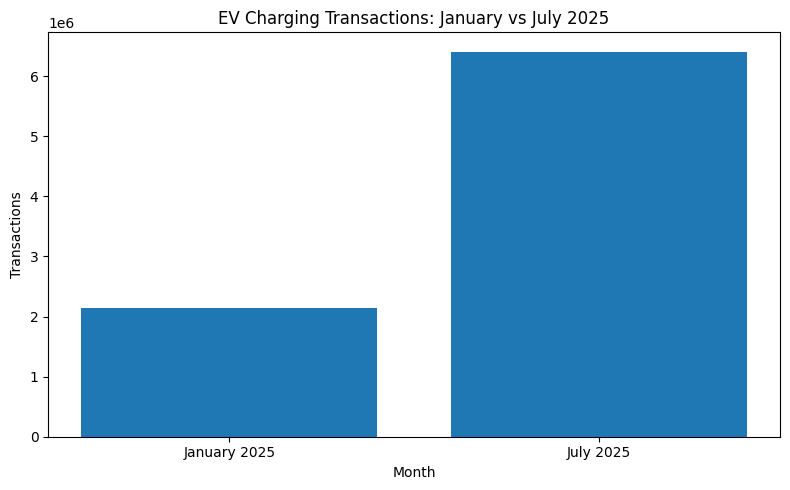

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    executive_kpis["month"],
    executive_kpis["transactions"]
)

plt.title("EV Charging Transactions: January vs July 2025")
plt.xlabel("Month")
plt.ylabel("Transactions")

plt.tight_layout()
plt.show()

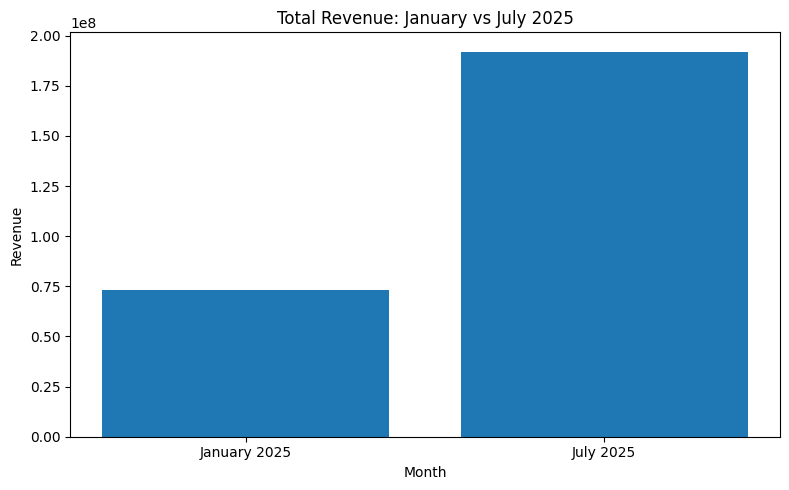

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    executive_kpis["month"],
    executive_kpis["total_revenue"]
)

plt.title("Total Revenue: January vs July 2025")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.tight_layout()
plt.show()

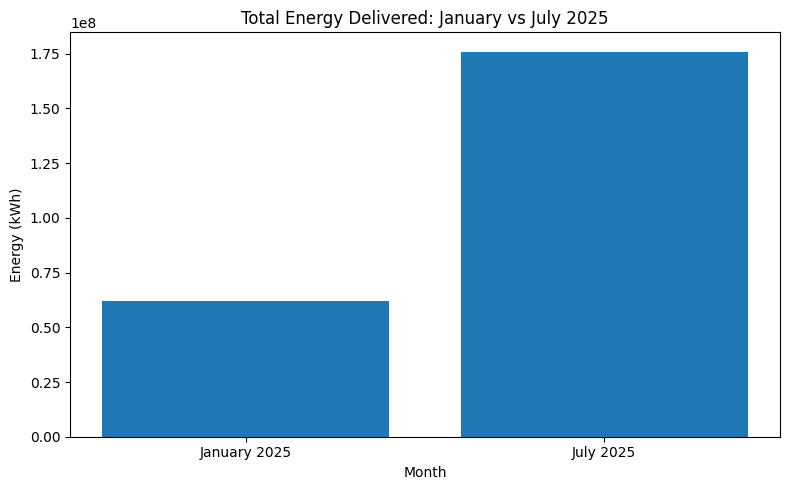

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    executive_kpis["month"],
    executive_kpis["total_energy_kwh"]
)

plt.title("Total Energy Delivered: January vs July 2025")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")

plt.tight_layout()
plt.show()

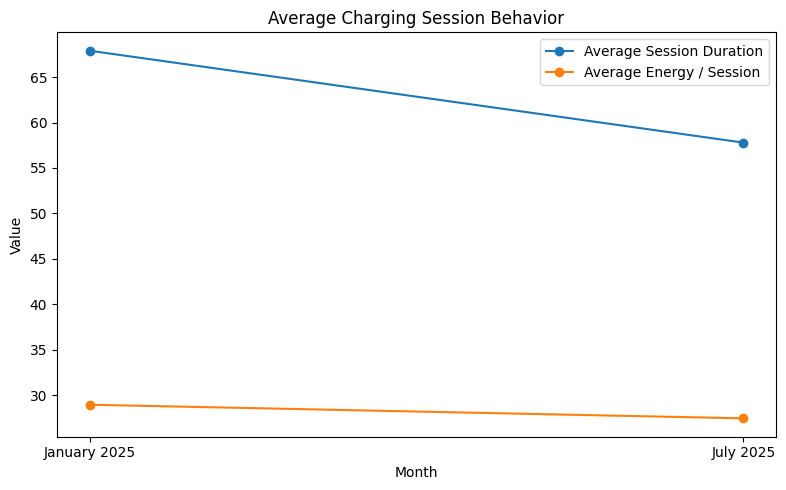

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    executive_kpis["month"],
    executive_kpis["avg_session_duration_min"],
    marker="o",
    label="Average Session Duration"
)

plt.plot(
    executive_kpis["month"],
    executive_kpis["avg_energy_per_session_kwh"],
    marker="o",
    label="Average Energy / Session"
)

plt.title("Average Charging Session Behavior")
plt.xlabel("Month")
plt.ylabel("Value")

plt.legend()
plt.tight_layout()
plt.show()

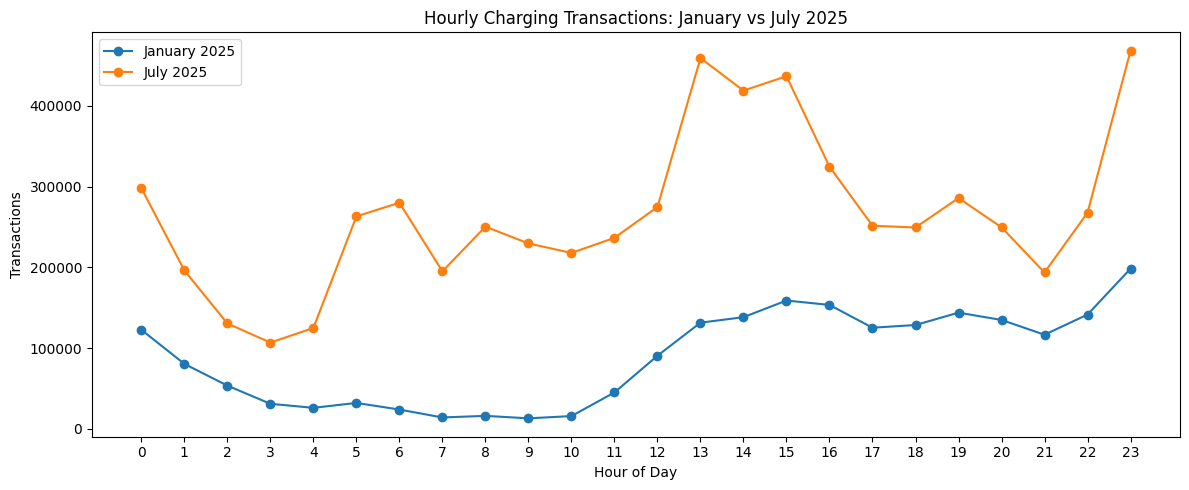

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_demand["charge_hour"],
    hourly_demand["transactions_january"],
    marker="o",
    label="January 2025"
)

plt.plot(
    hourly_demand["charge_hour"],
    hourly_demand["transactions_july"],
    marker="o",
    label="July 2025"
)

plt.title("Hourly Charging Transactions: January vs July 2025")
plt.xlabel("Hour of Day")
plt.ylabel("Transactions")
plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()

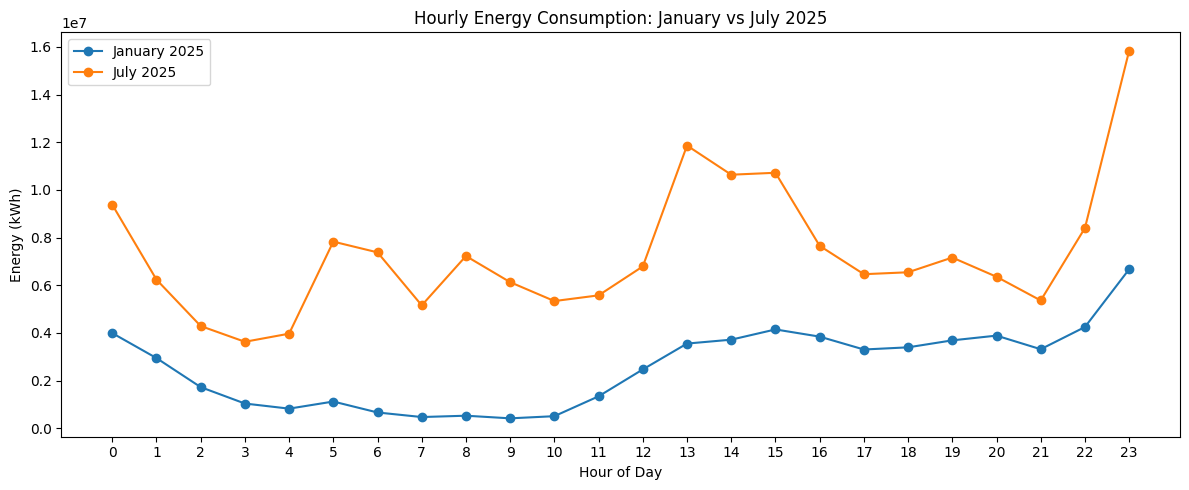

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_demand["charge_hour"],
    hourly_demand["total_energy_kwh_january"],
    marker="o",
    label="January 2025"
)

plt.plot(
    hourly_demand["charge_hour"],
    hourly_demand["total_energy_kwh_july"],
    marker="o",
    label="July 2025"
)

plt.title("Hourly Energy Consumption: January vs July 2025")
plt.xlabel("Hour of Day")
plt.ylabel("Energy (kWh)")
plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()

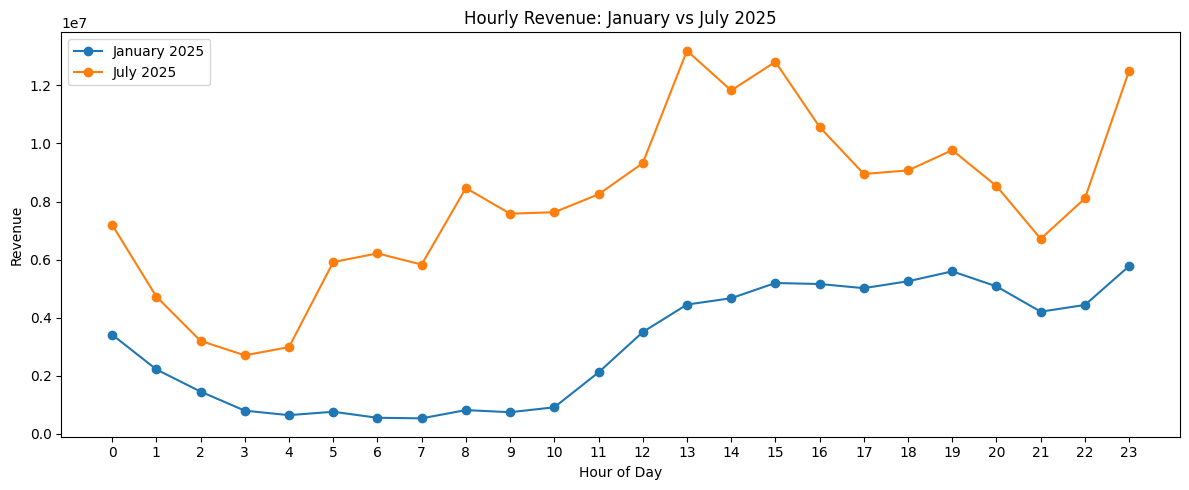

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    hourly_demand["charge_hour"],
    hourly_demand["total_revenue_january"],
    marker="o",
    label="January 2025"
)

plt.plot(
    hourly_demand["charge_hour"],
    hourly_demand["total_revenue_july"],
    marker="o",
    label="July 2025"
)

plt.title("Hourly Revenue: January vs July 2025")
plt.xlabel("Hour of Day")
plt.ylabel("Revenue")
plt.xticks(range(24))
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
jan_peak = hourly_demand.loc[
    hourly_demand["transactions_january"].idxmax()
]

jul_peak = hourly_demand.loc[
    hourly_demand["transactions_july"].idxmax()
]

print("JANUARY PEAK HOUR")
print(
    f"Hour: {int(jan_peak['charge_hour']):02d}:00"
)
print(
    f"Transactions: {jan_peak['transactions_january']:,.0f}"
)
print(
    f"Energy: {jan_peak['total_energy_kwh_january']:,.2f} kWh"
)
print(
    f"Revenue: ₹{jan_peak['total_revenue_january']:,.2f}"
)

print("\nJULY PEAK HOUR")
print(
    f"Hour: {int(jul_peak['charge_hour']):02d}:00"
)
print(
    f"Transactions: {jul_peak['transactions_july']:,.0f}"
)
print(
    f"Energy: {jul_peak['total_energy_kwh_july']:,.2f} kWh"
)
print(
    f"Revenue: ₹{jul_peak['total_revenue_july']:,.2f}"
)

JANUARY PEAK HOUR
Hour: 23:00
Transactions: 198,317
Energy: 6,674,237.55 kWh
Revenue: ₹5,777,764.10

JULY PEAK HOUR
Hour: 23:00
Transactions: 468,037
Energy: 15,838,410.71 kWh
Revenue: ₹12,502,858.44


In [ ]:
peak_transaction_growth = (
    (jul_peak["transactions_july"] -
     jan_peak["transactions_january"])
    / jan_peak["transactions_january"]
) * 100

print(
    f"Peak-hour transaction growth: "
    f"{peak_transaction_growth:.2f}%"
)

Peak-hour transaction growth: 136.00%


In [ ]:
hourly_kpi = hourly_demand.copy()

hourly_kpi["transaction_change_pct"] = (
    (
        hourly_kpi["transactions_july"]
        - hourly_kpi["transactions_january"]
    )
    / hourly_kpi["transactions_january"]
) * 100

hourly_kpi["energy_change_pct"] = (
    (
        hourly_kpi["total_energy_kwh_july"]
        - hourly_kpi["total_energy_kwh_january"]
    )
    / hourly_kpi["total_energy_kwh_january"]
) * 100

hourly_kpi["revenue_change_pct"] = (
    (
        hourly_kpi["total_revenue_july"]
        - hourly_kpi["total_revenue_january"]
    )
    / hourly_kpi["total_revenue_january"]
) * 100

hourly_kpi.to_csv(
    f"{dashboard_path}/hourly_kpi.csv",
    index=False
)

print(hourly_kpi)

    charge_hour  transactions_january  total_energy_kwh_january  \
0             0                122691              3.995613e+06   
1             1                 80557              2.948134e+06   
2             2                 53627              1.730410e+06   
3             3                 31138              1.041713e+06   
4             4                 26148              8.276547e+05   
5             5                 32224              1.125685e+06   
6             6                 24021              6.665063e+05   
7             7                 14231              4.754295e+05   
8             8                 16220              5.312343e+05   
9             9                 13152              4.208326e+05   
10           10                 15944              5.115609e+05   
11           11                 45194              1.344598e+06   
12           12                 90605              2.472450e+06   
13           13                131523              3.556693e+0

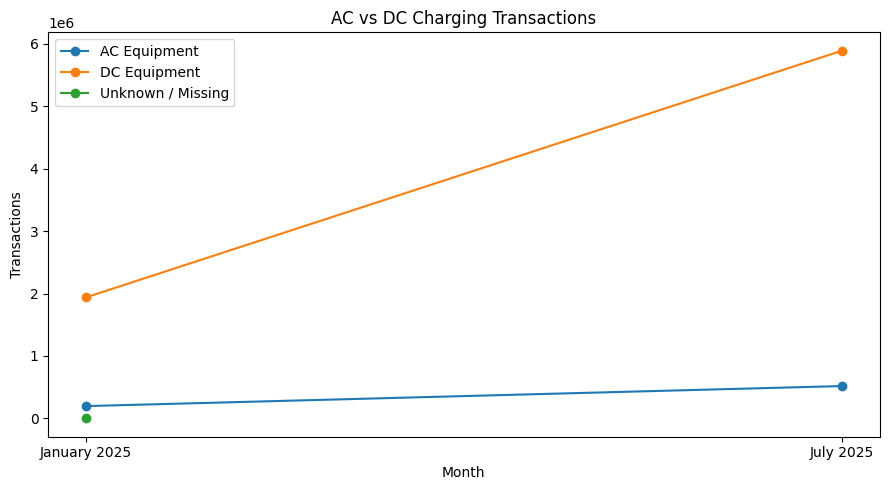

In [ ]:
plt.figure(figsize=(9, 5))

for equipment_type in equipment_performance["equipment_type"].dropna().unique():
    data = equipment_performance[
        equipment_performance["equipment_type"] == equipment_type
    ]

    plt.plot(
        data["month"],
        data["transactions"],
        marker="o",
        label=equipment_type
    )

plt.title("AC vs DC Charging Transactions")
plt.xlabel("Month")
plt.ylabel("Transactions")
plt.legend()

plt.tight_layout()
plt.show()

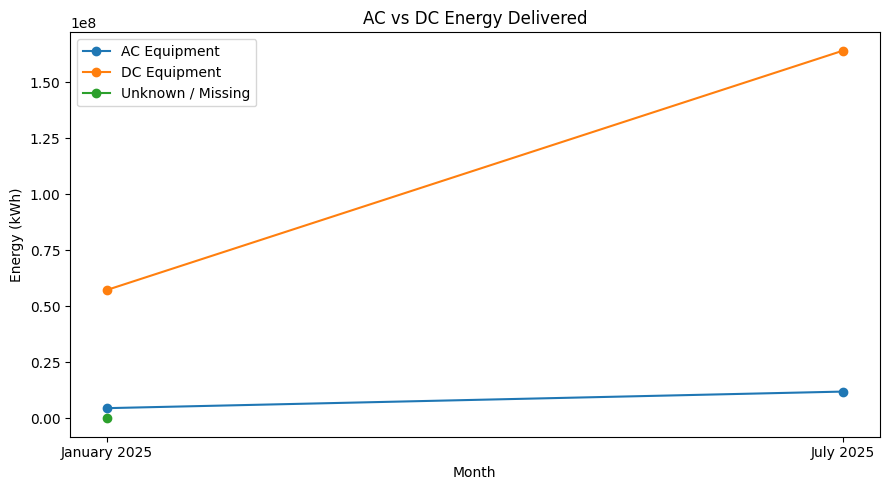

In [ ]:
plt.figure(figsize=(9, 5))

for equipment_type in equipment_performance["equipment_type"].dropna().unique():
    data = equipment_performance[
        equipment_performance["equipment_type"] == equipment_type
    ]

    plt.plot(
        data["month"],
        data["total_energy_kwh"],
        marker="o",
        label=equipment_type
    )

plt.title("AC vs DC Energy Delivered")
plt.xlabel("Month")
plt.ylabel("Energy (kWh)")
plt.legend()

plt.tight_layout()
plt.show()

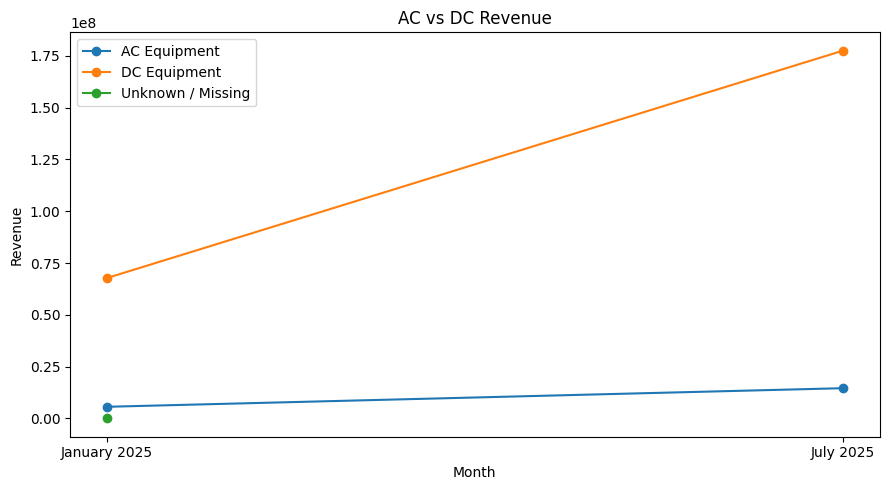

In [ ]:
plt.figure(figsize=(9, 5))

for equipment_type in equipment_performance["equipment_type"].dropna().unique():
    data = equipment_performance[
        equipment_performance["equipment_type"] == equipment_type
    ]

    plt.plot(
        data["month"],
        data["total_revenue"],
        marker="o",
        label=equipment_type
    )

plt.title("AC vs DC Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.legend()

plt.tight_layout()
plt.show()

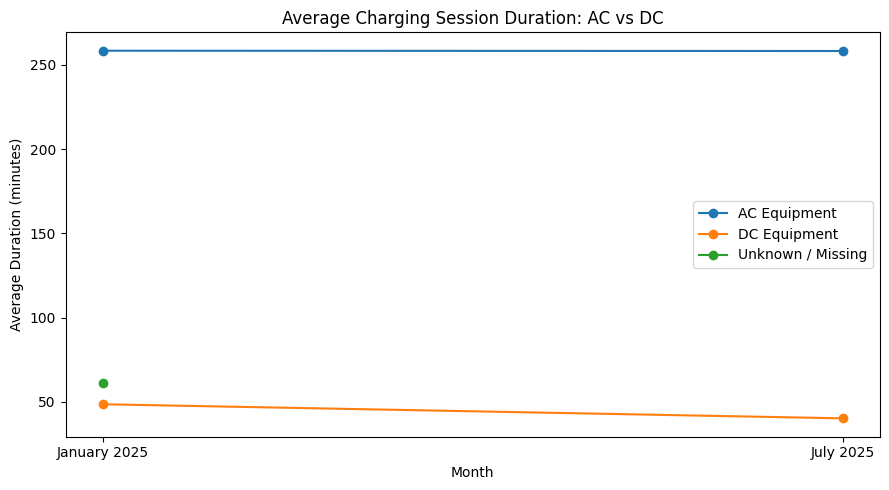

In [ ]:
plt.figure(figsize=(9, 5))

for equipment_type in equipment_performance["equipment_type"].dropna().unique():
    data = equipment_performance[
        equipment_performance["equipment_type"] == equipment_type
    ]

    plt.plot(
        data["month"],
        data["avg_duration_min"],
        marker="o",
        label=equipment_type
    )

plt.title("Average Charging Session Duration: AC vs DC")
plt.xlabel("Month")
plt.ylabel("Average Duration (minutes)")
plt.legend()

plt.tight_layout()
plt.show()

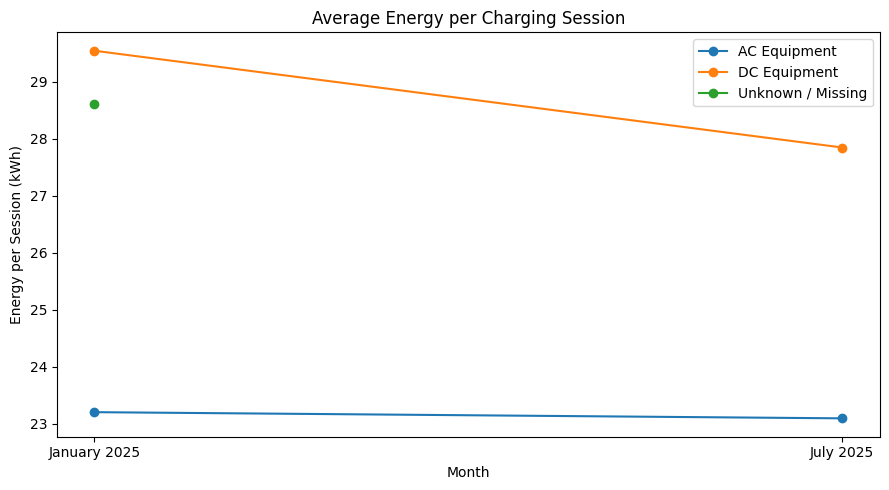

In [ ]:
plt.figure(figsize=(9, 5))

for equipment_type in equipment_performance["equipment_type"].dropna().unique():
    data = equipment_performance[
        equipment_performance["equipment_type"] == equipment_type
    ]

    plt.plot(
        data["month"],
        data["avg_energy_per_session_kwh"],
        marker="o",
        label=equipment_type
    )

plt.title("Average Energy per Charging Session")
plt.xlabel("Month")
plt.ylabel("Energy per Session (kWh)")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print("AC/DC PERFORMANCE SUMMARY")
print()

print(
    equipment_performance[
        [
            "month",
            "equipment_type",
            "transactions",
            "total_energy_kwh",
            "total_revenue",
            "avg_duration_min",
            "avg_energy_per_session_kwh",
            "avg_revenue_per_session"
        ]
    ].to_string(index=False)
)

AC/DC PERFORMANCE SUMMARY

       month    equipment_type  transactions  total_energy_kwh  total_revenue  avg_duration_min  avg_energy_per_session_kwh  avg_revenue_per_session
January 2025      AC Equipment        197225      4.576156e+06   5.610996e+06        258.406997                   23.202720                28.449719
January 2025      DC Equipment       1938830      5.728760e+07   6.773559e+07         48.523156                   29.547509                34.936322
January 2025 Unknown / Missing          1179      3.373989e+04   3.606533e+04         61.230817                   28.617377                30.589763
   July 2025      AC Equipment        518163      1.196660e+07   1.458713e+07        258.228970                   23.094279                28.151629
   July 2025      DC Equipment       5889298      1.640080e+08   1.774667e+08         40.156035                   27.848478                30.133764


In [ ]:
station_performance = pd.read_csv(
    f"{dashboard_path}/station_performance.csv"
)

print("Station performance loaded.")
print("Rows:", len(station_performance))
print("Columns:", len(station_performance.columns))

print("\nMonths:")
print(station_performance["month"].value_counts())

Station performance loaded.
Rows: 14218
Columns: 13

Months:
month
July 2025       7972
January 2025    6246
Name: count, dtype: int64


In [ ]:
jan_top = (
    station_performance[
        station_performance["month"] == "January 2025"
    ]
    .nlargest(10, "transactions")
)

jul_top = (
    station_performance[
        station_performance["month"] == "July 2025"
    ]
    .nlargest(10, "transactions")
)

print("TOP 10 STATIONS — JANUARY")
print(
    jan_top[
        [
            "station_id",
            "transactions",
            "total_energy_kwh",
            "total_revenue",
            "piles_num",
            "charging_gun_num"
        ]
    ].to_string(index=False)
)

print("\nTOP 10 STATIONS — JULY")
print(
    jul_top[
        [
            "station_id",
            "transactions",
            "total_energy_kwh",
            "total_revenue",
            "piles_num",
            "charging_gun_num"
        ]
    ].to_string(index=False)
)

TOP 10 STATIONS — JANUARY
station_id  transactions  total_energy_kwh  total_revenue  piles_num  charging_gun_num
 ST_005238         23369        482378.024      705497.60      106.0             116.0
 ST_001611         15186        360924.910      506789.31       29.0              56.0
 ST_006028         13912        336306.540      318652.25       42.0              84.0
 ST_002276         11168        189642.990      282039.50       50.0              50.0
 ST_006360         11146        244016.400      251445.67       40.0              80.0
 ST_006237          9228        279266.700      245964.71       40.0              79.0
 ST_008533          8528        223620.450      284331.48       30.0              54.0
 ST_004847          7932        186364.970      190797.50        6.0              72.0
 ST_006049          7626        238572.110      190655.43        5.0              62.0
 ST_003567          7266        319510.872      312487.95       25.0              50.0

TOP 10 STATIONS 

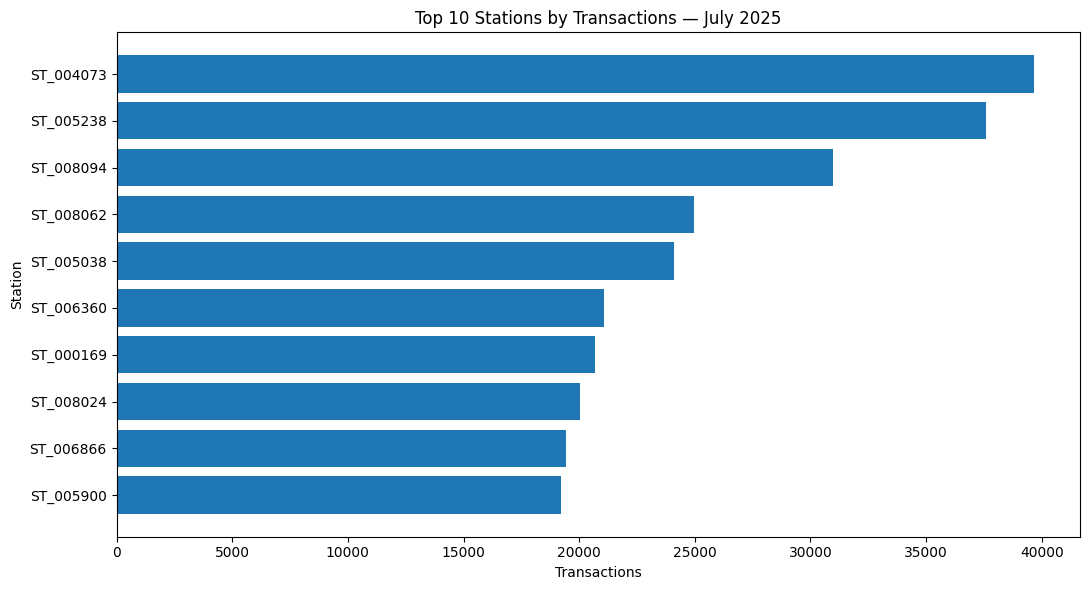

In [ ]:
plt.figure(figsize=(11, 6))

plt.barh(
    jul_top["station_id"][::-1],
    jul_top["transactions"][::-1]
)

plt.title("Top 10 Stations by Transactions — July 2025")
plt.xlabel("Transactions")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

In [ ]:
jul_gun = (
    station_performance[
        station_performance["month"] == "July 2025"
    ]
    .dropna(subset=["charging_gun_num"])
)

jul_gun = jul_gun[
    jul_gun["charging_gun_num"] > 0
]

top_gun_utilization = (
    jul_gun
    .nlargest(10, "transactions_per_gun")
)

print(
    top_gun_utilization[
        [
            "station_id",
            "transactions",
            "charging_gun_num",
            "transactions_per_gun",
            "station_power_kw",
            "total_revenue",
            "construction_site"
        ]
    ].to_string(index=False)
)

station_id  transactions  charging_gun_num  transactions_per_gun  station_power_kw  total_revenue construction_site
 ST_007817          7960               8.0            995.000000             480.0      183833.59             路边停车位
 ST_005744          2589               4.0            647.250000             240.0       84374.68              交通枢纽
 ST_004154         12318              20.0            615.900000            1200.0      232206.49                其他
 ST_000600          1219               2.0            609.500000              76.5       19636.95                其他
 ST_007332         12145              20.0            607.250000             960.0      280624.82                其他
 ST_006905          7226              12.0            602.166667             720.0      176767.50                其他
 ST_004235          6012              10.0            601.200000             480.0      146550.61                其他
 ST_000732          1180               2.0            590.000000        

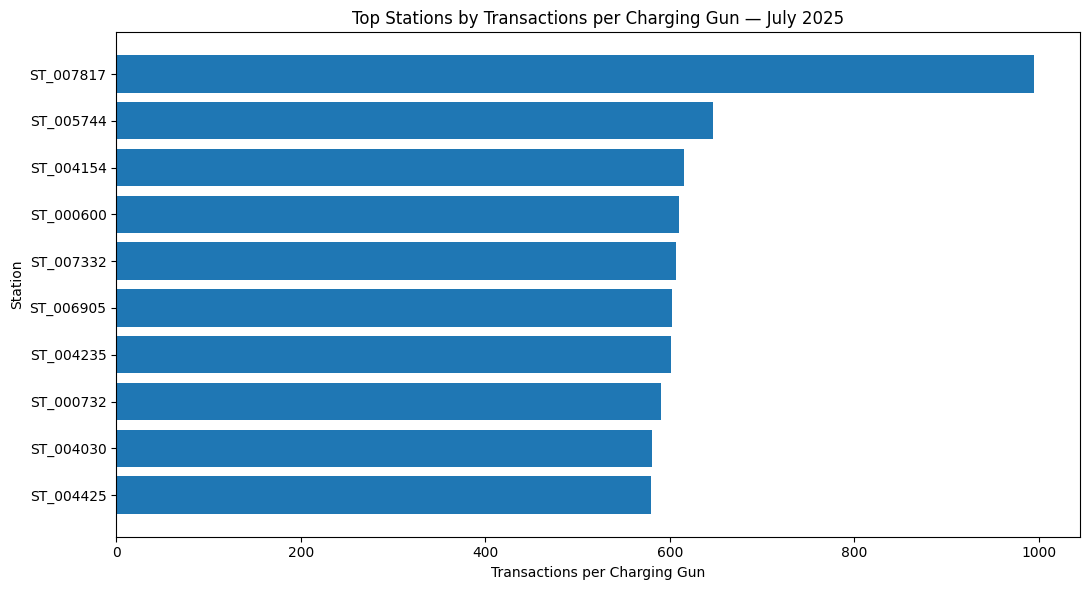

In [ ]:
plt.figure(figsize=(11, 6))

plt.barh(
    top_gun_utilization["station_id"][::-1],
    top_gun_utilization["transactions_per_gun"][::-1]
)

plt.title("Top Stations by Transactions per Charging Gun — July 2025")
plt.xlabel("Transactions per Charging Gun")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

In [ ]:
jul_mw = (
    station_performance[
        station_performance["month"] == "July 2025"
    ]
    .dropna(subset=["station_power_kw"])
)

jul_mw = jul_mw[
    jul_mw["station_power_kw"] > 0
]

top_mw_efficiency = (
    jul_mw
    .nlargest(10, "transactions_per_mw")
)

print(
    top_mw_efficiency[
        [
            "station_id",
            "transactions",
            "station_power_kw",
            "transactions_per_mw",
            "piles_num",
            "charging_gun_num",
            "total_revenue",
            "construction_site"
        ]
    ].to_string(index=False)
)

station_id  transactions  station_power_kw  transactions_per_mw  piles_num  charging_gun_num  total_revenue construction_site
 ST_007817          7960             480.0         16583.333333        4.0               8.0      183833.59             路边停车位
 ST_000595          1008              63.0         16000.000000        2.0               2.0       17728.28                其他
 ST_005148           112               7.0         16000.000000        1.0               1.0        2103.36         大型建筑配建停车场
 ST_000600          1219              76.5         15934.640523        2.0               2.0       19636.95                其他
 ST_000744           745              49.0         15204.081633        7.0               7.0       12108.39               居住区
 ST_008049          7329             500.0         14658.000000        2.0              24.0      181364.30              公共机构
 ST_008076         13900            1000.0         13900.000000        4.0              46.0      343811.76           

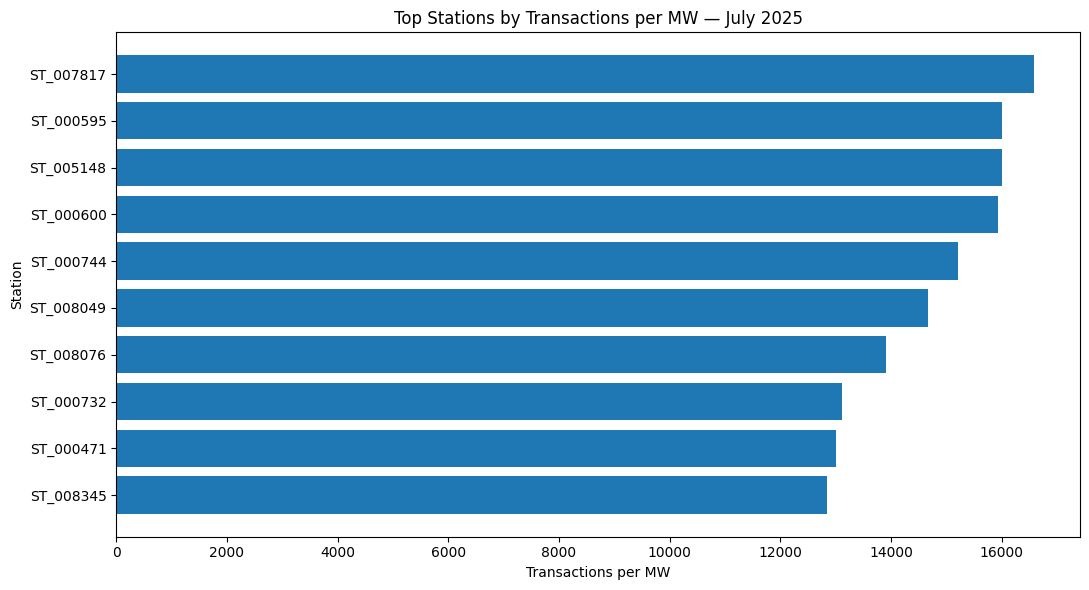

In [ ]:
plt.figure(figsize=(11, 6))

plt.barh(
    top_mw_efficiency["station_id"][::-1],
    top_mw_efficiency["transactions_per_mw"][::-1]
)

plt.title("Top Stations by Transactions per MW — July 2025")
plt.xlabel("Transactions per MW")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

performance_segment
Lower Demand / Lower Capacity    3107
High Demand / High Capacity      3107
High Demand / Lower Capacity      879
Lower Demand / High Capacity      879
Name: count, dtype: int64


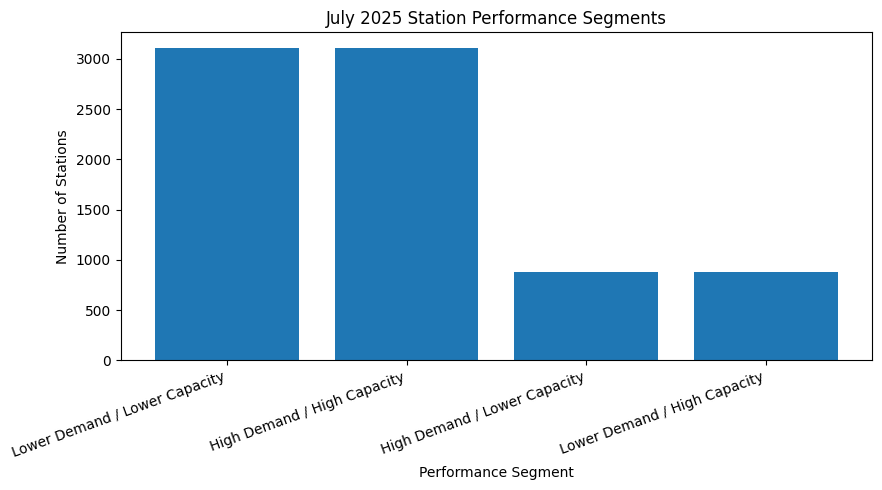

In [ ]:
jul_segments = (
    station_performance[
        station_performance["month"] == "July 2025"
    ]
    ["performance_segment"]
    .value_counts()
)

print(jul_segments)

plt.figure(figsize=(9, 5))

plt.bar(
    jul_segments.index,
    jul_segments.values
)

plt.title("July 2025 Station Performance Segments")
plt.xlabel("Performance Segment")
plt.ylabel("Number of Stations")

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()
plt.show()

In [ ]:
jul_high_demand_low_capacity = (
    station_performance[
        (station_performance["month"] == "July 2025") &
        (
            station_performance["performance_segment"]
            == "High Demand / Lower Capacity"
        )
    ]
    .sort_values(
        "transactions",
        ascending=False
    )
)

top_20_capacity_candidates = (
    jul_high_demand_low_capacity
    .head(20)
)

print(
    top_20_capacity_candidates[
        [
            "station_id",
            "transactions",
            "station_power_kw",
            "piles_num",
            "charging_gun_num",
            "transactions_per_gun",
            "transactions_per_mw",
            "total_energy_kwh",
            "total_revenue",
            "construction_site"
        ]
    ].to_string(index=False)
)

station_id  transactions  station_power_kw  piles_num  charging_gun_num  transactions_per_gun  transactions_per_mw  total_energy_kwh  total_revenue construction_site
 ST_000600          1219              76.5        2.0               2.0            609.500000         15934.640523         19535.910       19636.95                其他
 ST_007050          1212             130.0       11.0              12.0            101.000000          9323.076923         33361.520       48437.27                其他
 ST_000732          1180              90.0        2.0               2.0            590.000000         13111.111111         22194.080       22386.84              交通枢纽
 ST_000725          1133              90.0        2.0               2.0            566.500000         12588.888889         21296.720       21432.75                其他
 ST_000736          1083              90.0        2.0               2.0            541.500000         12033.333333         18134.940       18254.77                其他
 ST_

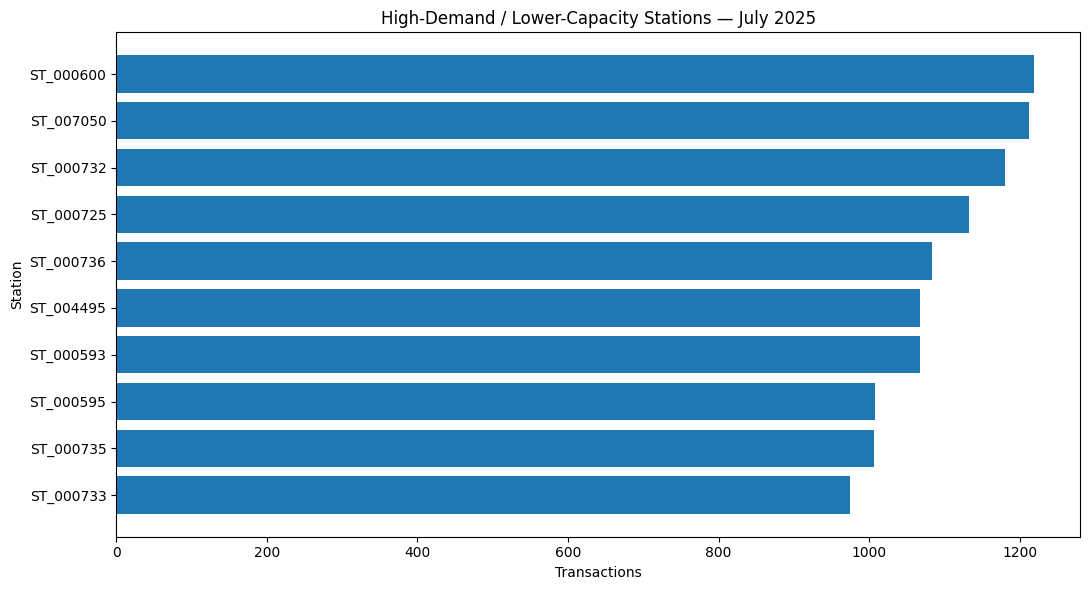

In [ ]:
top_capacity_candidates = (
    jul_high_demand_low_capacity
    .head(10)
)

plt.figure(figsize=(11, 6))

plt.barh(
    top_capacity_candidates["station_id"][::-1],
    top_capacity_candidates["transactions"][::-1]
)

plt.title(
    "High-Demand / Lower-Capacity Stations — July 2025"
)

plt.xlabel("Transactions")
plt.ylabel("Station")

plt.tight_layout()
plt.show()

In [ ]:
station_dashboard_summary = (
    station_performance[
        station_performance["month"] == "July 2025"
    ][
        [
            "station_id",
            "transactions",
            "total_energy_kwh",
            "total_revenue",
            "station_power_kw",
            "piles_num",
            "charging_gun_num",
            "transactions_per_gun",
            "transactions_per_mw",
            "performance_segment",
            "construction_site"
        ]
    ]
    .copy()
)

station_dashboard_summary.to_csv(
    f"{dashboard_path}/july_station_dashboard.csv",
    index=False
)

print(
    "Saved:",
    f"{dashboard_path}/july_station_dashboard.csv"
)

print(
    "Rows:",
    len(station_dashboard_summary)
)

Saved: /content/EVChargeIQ_dashboard/july_station_dashboard.csv
Rows: 7972


In [ ]:
site_performance = pd.read_csv(
    f"{dashboard_path}/construction_site_performance.csv"
)

print("Construction-site data loaded.")
print("Rows:", len(site_performance))
print("\nMonths:")
print(site_performance["month"].value_counts())

Construction-site data loaded.
Rows: 33

Months:
month
January 2025    17
July 2025       16
Name: count, dtype: int64


In [ ]:
jul_sites = (
    site_performance[
        site_performance["month"] == "July 2025"
    ]
    .sort_values(
        "transactions",
        ascending=False
    )
)

print(
    jul_sites[
        [
            "construction_site",
            "stations",
            "transactions",
            "total_energy_kwh",
            "total_revenue",
            "avg_transactions_per_station",
            "avg_revenue_per_station"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

construction_site  stations  transactions  total_energy_kwh  total_revenue  avg_transactions_per_station  avg_revenue_per_station
               其他      2382       2709477      7.398568e+07   7.602685e+07                   1137.479849             31917.231423
             公共机构      1615       1403296      3.939661e+07   4.207916e+07                    868.913932             26055.204609
        大型建筑配建停车场       511        558671      1.541416e+07   1.884456e+07                   1093.289628             36877.815902
              居住区      1208        445579      1.154467e+07   1.242947e+07                    368.856788             10289.297144
              写字楼       473        414894      1.135595e+07   1.440226e+07                    877.154334             30448.757907
            企事业单位      1022        184500      4.996923e+06   5.950522e+06                    180.528376              5822.428611
           大型文体设施       115        175506      4.574364e+06   5.142529e+06                

In [ ]:
!apt-get -qq update
!apt-get -qq install fonts-noto-cjk

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-noto-cjk.
(Reading database ... 118332 files and directories currently installed.)
Preparing to unpack .../fonts-noto-cjk_1%3a20220127+repack1-1_all.deb ...
Unpacking fonts-noto-cjk (1:20220127+repack1-1) ...
Setting up fonts-noto-cjk (1:20220127+repack1-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont(
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
)

plt.rcParams["font.family"] = "Noto Sans CJK JP"

print("Chinese font configured successfully.")

Chinese font configured successfully.


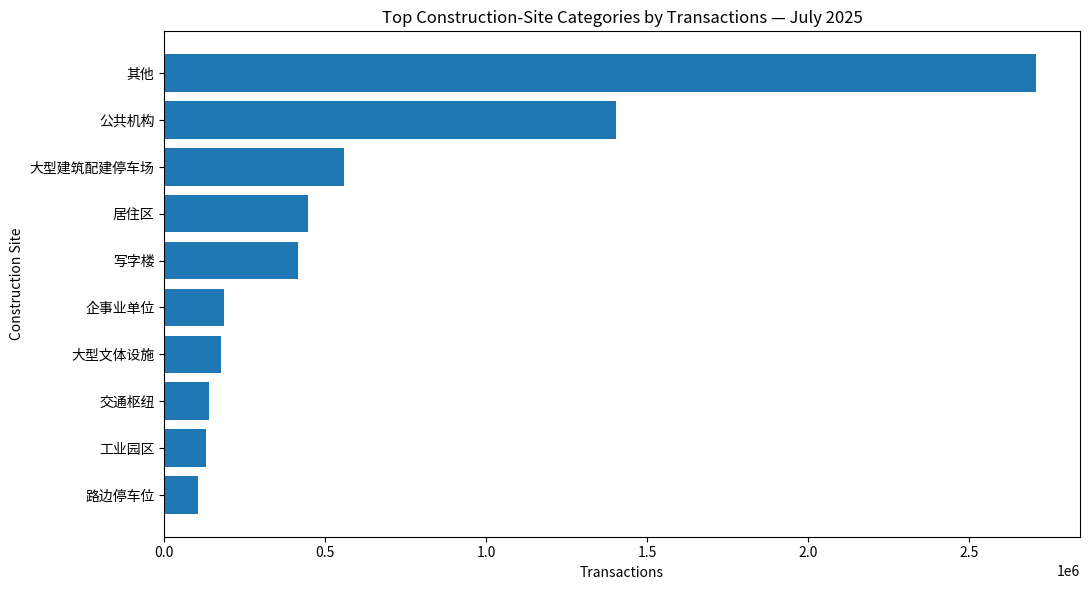

In [ ]:
top_sites = jul_sites.head(10)

plt.figure(figsize=(11, 6))

plt.barh(
    top_sites["construction_site"][::-1],
    top_sites["transactions"][::-1]
)

plt.title(
    "Top Construction-Site Categories by Transactions — July 2025"
)

plt.xlabel("Transactions")
plt.ylabel("Construction Site")

plt.tight_layout()
plt.show()

In [ ]:
top_site_efficiency = (
    jul_sites
    .sort_values(
        "avg_transactions_per_station",
        ascending=False
    )
    .head(10)
)

print(
    top_site_efficiency[
        [
            "construction_site",
            "stations",
            "transactions",
            "avg_transactions_per_station",
            "avg_station_power_kw",
            "total_revenue"
        ]
    ].to_string(index=False)
)

construction_site  stations  transactions  avg_transactions_per_station  avg_station_power_kw  total_revenue
            加油加气站         2          9210                   4605.000000           1080.000000   2.408570e+05
             交通枢纽        63        139241                   2210.174603           1004.714286   5.340686e+06
            路边停车位        54        104766                   1940.111111           1463.370370   2.854415e+06
          城际高速服务区        51         94742                   1857.686275            744.705882   2.868511e+06
           大型文体设施       115        175506                   1526.139130           1425.513043   5.142529e+06
               其他      2382       2709477                   1137.479849            479.617632   7.602685e+07
        大型建筑配建停车场       511        558671                   1093.289628            854.520939   1.884456e+07
              写字楼       473        414894                    877.154334            651.120507   1.440226e+07
             公共机构  

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont(
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
)

plt.rcParams["font.family"] = "Noto Sans CJK JP"

print("Chinese font configured successfully.")

Chinese font configured successfully.


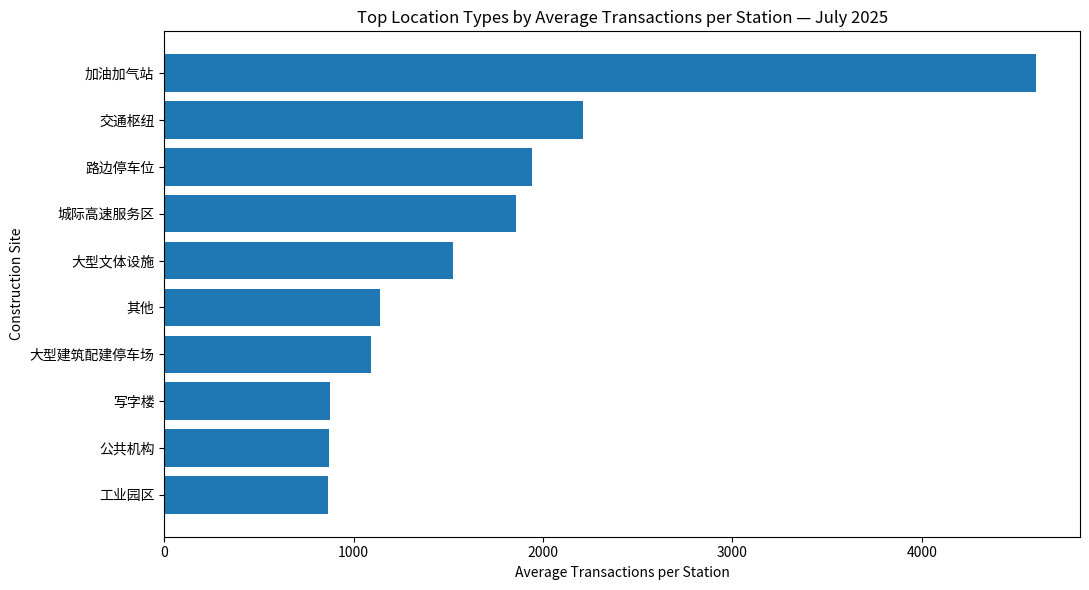

In [ ]:
plt.figure(figsize=(11, 6))

plt.barh(
    top_site_efficiency["construction_site"][::-1],
    top_site_efficiency["avg_transactions_per_station"][::-1]
)

plt.title(
    "Top Location Types by Average Transactions per Station — July 2025"
)

plt.xlabel("Average Transactions per Station")
plt.ylabel("Construction Site")

plt.tight_layout()
plt.show()

In [ ]:
top_revenue_sites = (
    jul_sites
    .sort_values(
        "avg_revenue_per_station",
        ascending=False
    )
    .head(10)
)

print(
    top_revenue_sites[
        [
            "construction_site",
            "stations",
            "avg_revenue_per_station",
            "avg_transactions_per_station",
            "avg_station_power_kw"
        ]
    ].to_string(index=False)
)

construction_site  stations  avg_revenue_per_station  avg_transactions_per_station  avg_station_power_kw
            加油加气站         2            120428.525000                   4605.000000           1080.000000
             交通枢纽        63             84772.787460                   2210.174603           1004.714286
          城际高速服务区        51             56245.306275                   1857.686275            744.705882
            路边停车位        54             52859.546111                   1940.111111           1463.370370
           大型文体设施       115             44717.639217                   1526.139130           1425.513043
             城市绿地        28             37021.102143                    617.214286            493.142857
        大型建筑配建停车场       511             36877.815902                   1093.289628            854.520939
               其他      2382             31917.231423                   1137.479849            479.617632
              写字楼       473             30448.757907   

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont(
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc"
)

plt.rcParams["font.family"] = "Noto Sans CJK JP"

print("Chinese font configured successfully.")

Chinese font configured successfully.


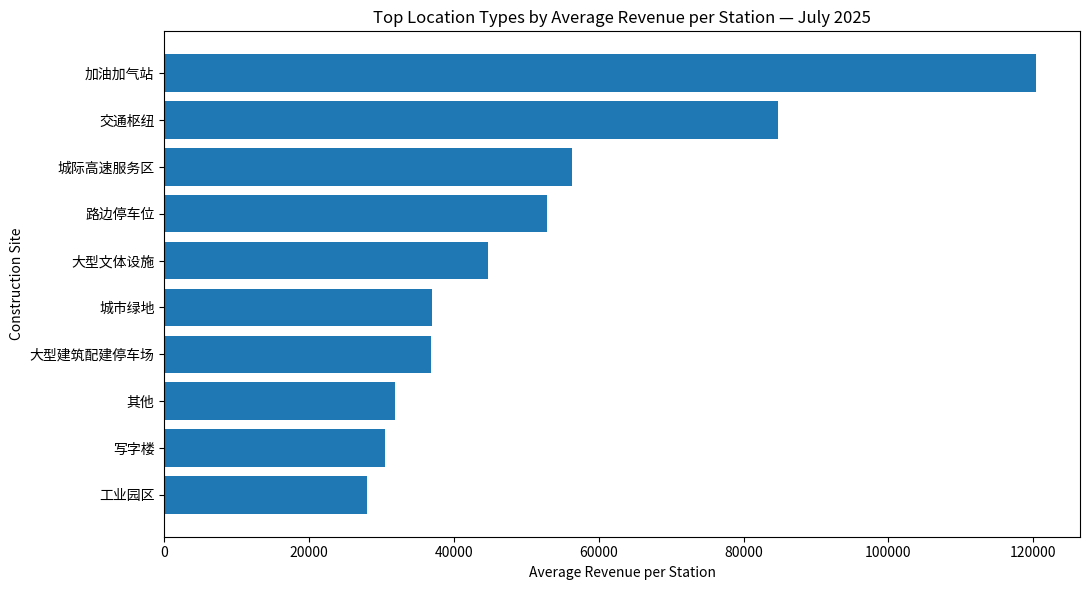

In [ ]:
plt.figure(figsize=(11, 6))

plt.barh(
    top_revenue_sites["construction_site"][::-1],
    top_revenue_sites["avg_revenue_per_station"][::-1]
)

plt.title(
    "Top Location Types by Average Revenue per Station — July 2025"
)

plt.xlabel("Average Revenue per Station")
plt.ylabel("Construction Site")

plt.tight_layout()
plt.show()

In [ ]:
location_strategy = (
    jul_sites[
        [
            "construction_site",
            "stations",
            "transactions",
            "total_energy_kwh",
            "total_revenue",
            "avg_transactions_per_station",
            "avg_revenue_per_station",
            "avg_station_power_kw"
        ]
    ]
    .copy()
)

location_strategy["revenue_per_transaction"] = (
    location_strategy["total_revenue"]
    / location_strategy["transactions"]
)

print(
    location_strategy
    .sort_values(
        "avg_revenue_per_station",
        ascending=False
    )
    .to_string(index=False)
)

construction_site  stations  transactions  total_energy_kwh  total_revenue  avg_transactions_per_station  avg_revenue_per_station  avg_station_power_kw  revenue_per_transaction
            加油加气站         2          9210      2.066681e+05   2.408570e+05                   4605.000000            120428.525000           1080.000000                26.151688
             交通枢纽        63        139241      4.343952e+06   5.340686e+06                   2210.174603             84772.787460           1004.714286                38.355697
          城际高速服务区        51         94742      2.310124e+06   2.868511e+06                   1857.686275             56245.306275            744.705882                30.277075
            路边停车位        54        104766      2.703688e+06   2.854415e+06                   1940.111111             52859.546111           1463.370370                27.245628
           大型文体设施       115        175506      4.574364e+06   5.142529e+06                   1526.139130           

In [ ]:
location_strategy.to_csv(
    f"{dashboard_path}/location_strategy.csv",
    index=False
)

print(
    "Saved:",
    f"{dashboard_path}/location_strategy.csv"
)

print("Rows:", len(location_strategy))

Saved: /content/EVChargeIQ_dashboard/location_strategy.csv
Rows: 16


In [ ]:
import matplotlib.pyplot as plt

jan = executive_kpis[
    executive_kpis["month"] == "January 2025"
].iloc[0]

jul = executive_kpis[
    executive_kpis["month"] == "July 2025"
].iloc[0]

transaction_growth = (
    (jul["transactions"] - jan["transactions"])
    / jan["transactions"]
) * 100

energy_growth = (
    (jul["total_energy_kwh"] - jan["total_energy_kwh"])
    / jan["total_energy_kwh"]
) * 100

revenue_growth = (
    (jul["total_revenue"] - jan["total_revenue"])
    / jan["total_revenue"]
) * 100

print("EVChargeIQ — Executive KPIs")
print("=" * 50)

print(f"January Transactions : {jan['transactions']:,.0f}")
print(f"July Transactions    : {jul['transactions']:,.0f}")
print(f"Transaction Growth   : {transaction_growth:.2f}%")

print()

print(f"January Energy       : {jan['total_energy_kwh']:,.0f} kWh")
print(f"July Energy          : {jul['total_energy_kwh']:,.0f} kWh")
print(f"Energy Growth        : {energy_growth:.2f}%")

print()

print(f"January Revenue      : ₹{jan['total_revenue']:,.2f}")
print(f"July Revenue         : ₹{jul['total_revenue']:,.2f}")
print(f"Revenue Growth       : {revenue_growth:.2f}%")

print()

print(
    f"Avg Session Duration : "
    f"{jan['avg_session_duration_min']:.2f} → "
    f"{jul['avg_session_duration_min']:.2f} min"
)

print(
    f"Avg Energy/Session   : "
    f"{jan['avg_energy_per_session_kwh']:.2f} → "
    f"{jul['avg_energy_per_session_kwh']:.2f} kWh"
)

print(
    f"Avg Revenue/Session  : "
    f"₹{jan['avg_revenue_per_session']:.2f} → "
    f"₹{jul['avg_revenue_per_session']:.2f}"
)

EVChargeIQ — Executive KPIs
January Transactions : 2,137,234
July Transactions    : 6,407,461
Transaction Growth   : 199.80%

January Energy       : 61,897,490 kWh
July Energy          : 175,974,600 kWh
Energy Growth        : 184.30%

January Revenue      : ₹73,382,650.00
July Revenue         : ₹192,053,800.00
Revenue Growth       : 161.72%

Avg Session Duration : 67.90 → 57.79 min
Avg Energy/Session   : 28.96 → 27.46 kWh
Avg Revenue/Session  : ₹34.34 → ₹29.97


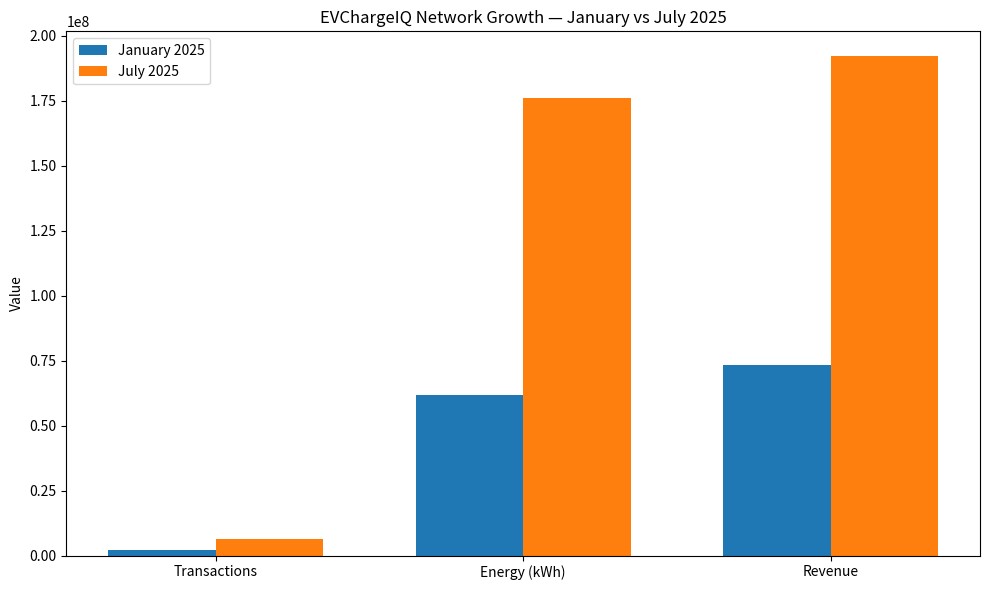

In [ ]:
metrics = [
    "Transactions",
    "Energy (kWh)",
    "Revenue"
]

jan_values = [
    jan["transactions"],
    jan["total_energy_kwh"],
    jan["total_revenue"]
]

jul_values = [
    jul["transactions"],
    jul["total_energy_kwh"],
    jul["total_revenue"]
]

x = range(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    [i - width / 2 for i in x],
    jan_values,
    width=width,
    label="January 2025"
)

plt.bar(
    [i + width / 2 for i in x],
    jul_values,
    width=width,
    label="July 2025"
)

plt.xticks(
    list(x),
    metrics
)

plt.title(
    "EVChargeIQ Network Growth — January vs July 2025"
)

plt.ylabel("Value")
plt.legend()

plt.tight_layout()
plt.show()

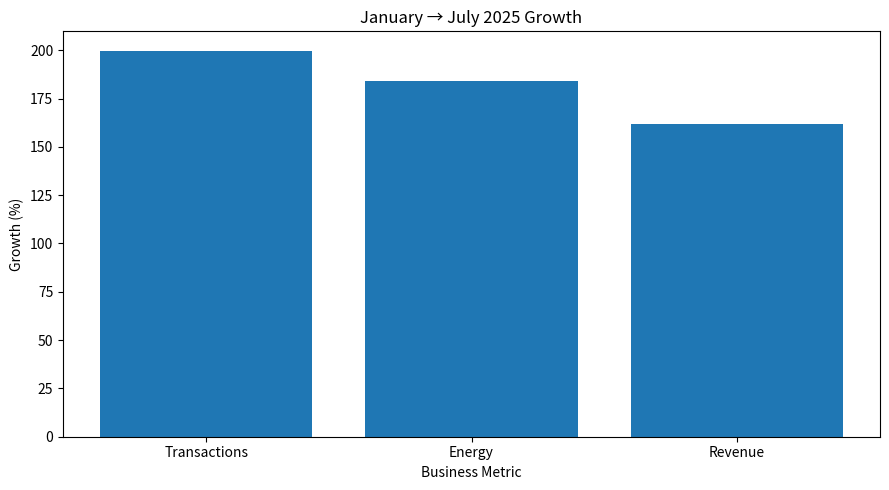

In [ ]:
growth_metrics = pd.DataFrame({
    "metric": [
        "Transactions",
        "Energy",
        "Revenue"
    ],
    "growth_pct": [
        transaction_growth,
        energy_growth,
        revenue_growth
    ]
})

plt.figure(figsize=(9, 5))

plt.bar(
    growth_metrics["metric"],
    growth_metrics["growth_pct"]
)

plt.title(
    "January → July 2025 Growth"
)

plt.xlabel("Business Metric")
plt.ylabel("Growth (%)")

plt.tight_layout()
plt.show()

In [ ]:
print("=" * 70)
print("EVChargeIQ — EXECUTIVE INSIGHTS")
print("=" * 70)

print(
    f"\n1. NETWORK GROWTH"
    f"\n   Transactions increased by {transaction_growth:.1f}% "
    f"from January to July."
)

print(
    f"\n2. ENERGY DEMAND"
    f"\n   Energy delivered increased by {energy_growth:.1f}%."
)

print(
    f"\n3. REVENUE"
    f"\n   Revenue increased by {revenue_growth:.1f}%."
)

print(
    "\n4. SESSION BEHAVIOR"
    f"\n   Average session duration fell from "
    f"{jan['avg_session_duration_min']:.1f} to "
    f"{jul['avg_session_duration_min']:.1f} minutes."
)

print(
    "\n5. PEAK DEMAND"
    "\n   23:00 was the peak charging hour in both periods."
)

print(
    "\n6. EQUIPMENT MIX"
    "\n   DC charging dominates both transaction volume "
    "and energy delivery."
)

print(
    "\n7. STATION STRATEGY"
    "\n   High-demand / lower-capacity stations should be "
    "prioritized for capacity review."
)

print(
    "\n8. LOCATION STRATEGY"
    "\n   Transport hubs, highway service areas and selected "
    "high-throughput site categories show strong station-level economics."
)

EVChargeIQ — EXECUTIVE INSIGHTS

1. NETWORK GROWTH
   Transactions increased by 199.8% from January to July.

2. ENERGY DEMAND
   Energy delivered increased by 184.3%.

3. REVENUE
   Revenue increased by 161.7%.

4. SESSION BEHAVIOR
   Average session duration fell from 67.9 to 57.8 minutes.

5. PEAK DEMAND
   23:00 was the peak charging hour in both periods.

6. EQUIPMENT MIX
   DC charging dominates both transaction volume and energy delivery.

7. STATION STRATEGY
   High-demand / lower-capacity stations should be prioritized for capacity review.

8. LOCATION STRATEGY
   Transport hubs, highway service areas and selected high-throughput site categories show strong station-level economics.


In [ ]:
from google.colab import drive
import os

drive.mount("/content/drive")

folder = "/content/drive/MyDrive/EVChargeIQ/PowerBI_Data"

print("Files permanently saved in Drive:")
print(os.listdir(folder))

Mounted at /content/drive
Files permanently saved in Drive:
['transactions_2025-07_processed.parquet', 'stations_public.parquet', 'transactions_2025-01_processed.parquet']


In [ ]:
import pandas as pd

folder = "/content/drive/MyDrive/EVChargeIQ/PowerBI_Data"

jan = pd.read_parquet(
    f"{folder}/transactions_2025-01_processed.parquet"
)

jul = pd.read_parquet(
    f"{folder}/transactions_2025-07_processed.parquet"
)

stations = pd.read_parquet(
    f"{folder}/stations_public.parquet"
)

print("January rows:", len(jan))
print("July rows:", len(jul))
print("Station rows:", len(stations))

print("\nJanuary columns:")
print(jan.columns.tolist())

print("\nStation columns:")
print(stations.columns.tolist())

January rows: 2137234
July rows: 6407461
Station rows: 8553

January columns:
['transaction_date', 'equipment_classification', 'rated_gun_power_kw', 'station_id', 'pile_id', 'duration_min', 'charge_start_time', 'charge_end_time', 'total_elec_kwh', 'total_elec_fee', 'total_service_fee', 'total_fee', 'charge_date', 'charge_hour', 'day_of_week', 'day_of_week_num', 'is_weekend', 'month', 'time_period', 'avg_charging_power_kw', 'energy_per_minute_kwh', 'equipment_type', 'electricity_cost_per_kwh', 'service_fee_share', 'geocoding', 'construction_site', 'station_total_power_kw', 'piles_num', 'dc_piles_num', 'ac_piles_num', 'charging_gun_num', 'dc_charging_gun_num', 'ac_charging_gun_num', 'dc_pile_share', 'dc_gun_share', 'power_per_pile_kw']

Station columns:
['geocoding', 'station_id', 'construction_site', 'station_total_power_kw', 'piles_num', 'dc_piles_num', 'ac_piles_num', 'charging_gun_num', 'dc_charging_gun_num', 'ac_charging_gun_num']


In [ ]:
import pandas as pd
import numpy as np
import os

# ============================================================
# EVChargeIQ — Power BI Dataset Generator
# ============================================================

folder = "/content/drive/MyDrive/EVChargeIQ/PowerBI_Data"

print("Loading permanent processed datasets...")

jan = pd.read_parquet(
    f"{folder}/transactions_2025-01_processed.parquet"
)

jul = pd.read_parquet(
    f"{folder}/transactions_2025-07_processed.parquet"
)

stations = pd.read_parquet(
    f"{folder}/stations_public.parquet"
)

print(f"January rows: {len(jan):,}")
print(f"July rows:    {len(jul):,}")
print(f"Stations:     {len(stations):,}")

# ============================================================
# 1. EXECUTIVE KPIs
# ============================================================

def create_kpis(df, month_name):

    return {
        "month": month_name,
        "transactions": len(df),
        "total_energy_kwh": df["total_elec_kwh"].sum(),
        "total_electricity_fee": df["total_elec_fee"].sum(),
        "total_service_fee": df["total_service_fee"].sum(),
        "total_revenue": df["total_fee"].sum(),
        "avg_session_duration_min": df["duration_min"].mean(),
        "avg_energy_per_session_kwh": df["total_elec_kwh"].mean(),
        "avg_revenue_per_session": df["total_fee"].mean()
    }

executive_kpis = pd.DataFrame([
    create_kpis(jan, "January 2025"),
    create_kpis(jul, "July 2025")
])

executive_kpis.to_csv(
    f"{folder}/executive_kpis.csv",
    index=False
)

# ============================================================
# 2. HOURLY DEMAND
# ============================================================

def hourly_summary(df, month_name):

    result = (
        df.groupby("charge_hour")
        .agg(
            transactions=("station_id", "size"),
            total_energy_kwh=("total_elec_kwh", "sum"),
            total_revenue=("total_fee", "sum")
        )
        .reset_index()
    )

    result["month"] = month_name

    return result

hourly_jan = hourly_summary(jan, "January 2025")
hourly_jul = hourly_summary(jul, "July 2025")

hourly_demand = pd.concat(
    [hourly_jan, hourly_jul],
    ignore_index=True
)

hourly_demand.to_csv(
    f"{folder}/hourly_demand.csv",
    index=False
)

# ============================================================
# 3. EQUIPMENT PERFORMANCE
# ============================================================

def equipment_summary(df, month_name):

    result = (
        df.groupby("equipment_type", dropna=False)
        .agg(
            transactions=("station_id", "size"),
            total_energy_kwh=("total_elec_kwh", "sum"),
            total_revenue=("total_fee", "sum"),
            avg_duration_min=("duration_min", "mean"),
            avg_energy_per_session_kwh=("total_elec_kwh", "mean"),
            avg_revenue_per_session=("total_fee", "mean")
        )
        .reset_index()
    )

    result["month"] = month_name

    return result

equipment_jan = equipment_summary(jan, "January 2025")
equipment_jul = equipment_summary(jul, "July 2025")

equipment_performance = pd.concat(
    [equipment_jan, equipment_jul],
    ignore_index=True
)

equipment_performance.to_csv(
    f"{folder}/equipment_performance.csv",
    index=False
)

# ============================================================
# 4. CONSTRUCTION-SITE PERFORMANCE
# ============================================================

def site_summary(df, month_name):

    result = (
        df.groupby("construction_site", dropna=False)
        .agg(
            transactions=("station_id", "size"),
            total_energy_kwh=("total_elec_kwh", "sum"),
            total_revenue=("total_fee", "sum")
        )
        .reset_index()
    )

    # Unique stations by construction site
    station_counts = (
        df.groupby("construction_site")["station_id"]
        .nunique()
        .reset_index(name="stations")
    )

    result = result.merge(
        station_counts,
        on="construction_site",
        how="left"
    )

    result["avg_transactions_per_station"] = (
        result["transactions"] /
        result["stations"]
    )

    result["avg_revenue_per_station"] = (
        result["total_revenue"] /
        result["stations"]
    )

    power = (
        df.groupby("construction_site")["station_total_power_kw"]
        .mean()
        .reset_index(name="avg_station_power_kw")
    )

    result = result.merge(
        power,
        on="construction_site",
        how="left"
    )

    result["month"] = month_name

    return result

site_jan = site_summary(jan, "January 2025")
site_jul = site_summary(jul, "July 2025")

construction_site_performance = pd.concat(
    [site_jan, site_jul],
    ignore_index=True
)

construction_site_performance.to_csv(
    f"{folder}/construction_site_performance.csv",
    index=False
)

# ============================================================
# 5. STATION PERFORMANCE
# ============================================================

def station_summary(df, month_name):

    result = (
        df.groupby("station_id")
        .agg(
            transactions=("station_id", "size"),
            total_energy_kwh=("total_elec_kwh", "sum"),
            total_revenue=("total_fee", "sum"),
            avg_duration_min=("duration_min", "mean"),
            station_power_kw=("station_total_power_kw", "first"),
            piles_num=("piles_num", "first"),
            charging_gun_num=("charging_gun_num", "first"),
            construction_site=("construction_site", "first")
        )
        .reset_index()
    )

    result["transactions_per_gun"] = (
        result["transactions"] /
        result["charging_gun_num"].replace(0, np.nan)
    )

    result["transactions_per_mw"] = (
        result["transactions"] /
        (result["station_power_kw"].replace(0, np.nan) / 1000)
    )

    result["month"] = month_name

    return result

station_jan = station_summary(jan, "January 2025")
station_jul = station_summary(jul, "July 2025")

station_performance = pd.concat(
    [station_jan, station_jul],
    ignore_index=True
)

# ============================================================
# Capacity segments
# ============================================================

for month_name in ["January 2025", "July 2025"]:

    mask = station_performance["month"] == month_name

    demand_median = station_performance.loc[
        mask, "transactions"
    ].median()

    capacity_median = station_performance.loc[
        mask, "station_power_kw"
    ].median()

    def classify(row):

        high_demand = row["transactions"] >= demand_median
        high_capacity = row["station_power_kw"] >= capacity_median

        if high_demand and high_capacity:
            return "High Demand / High Capacity"

        elif high_demand and not high_capacity:
            return "High Demand / Lower Capacity"

        elif not high_demand and high_capacity:
            return "Lower Demand / High Capacity"

        return "Lower Demand / Lower Capacity"

    station_performance.loc[mask, "performance_segment"] = (
        station_performance.loc[mask]
        .apply(classify, axis=1)
    )

station_performance.to_csv(
    f"{folder}/station_performance.csv",
    index=False
)

# ============================================================
# 6. STATION GROWTH
# ============================================================

jan_growth = station_jan[
    [
        "station_id",
        "transactions",
        "total_energy_kwh",
        "total_revenue"
    ]
].rename(
    columns={
        "transactions": "transactions_january",
        "total_energy_kwh": "january_energy_kwh",
        "total_revenue": "january_revenue"
    }
)

jul_growth = station_jul[
    [
        "station_id",
        "transactions",
        "total_energy_kwh",
        "total_revenue"
    ]
].rename(
    columns={
        "transactions": "transactions_july",
        "total_energy_kwh": "july_energy_kwh",
        "total_revenue": "july_revenue"
    }
)

station_growth = pd.merge(
    jan_growth,
    jul_growth,
    on="station_id",
    how="outer"
).fillna(0)

station_growth["transaction_change"] = (
    station_growth["transactions_july"] -
    station_growth["transactions_january"]
)

station_growth["transaction_growth_pct"] = np.where(
    station_growth["transactions_january"] > 0,
    (
        (
            station_growth["transactions_july"] -
            station_growth["transactions_january"]
        )
        / station_growth["transactions_january"]
    ) * 100,
    np.nan
)

station_growth["energy_growth_pct"] = np.where(
    station_growth["january_energy_kwh"] > 0,
    (
        (
            station_growth["july_energy_kwh"] -
            station_growth["january_energy_kwh"]
        )
        / station_growth["january_energy_kwh"]
    ) * 100,
    np.nan
)

station_growth["revenue_growth_pct"] = np.where(
    station_growth["january_revenue"] > 0,
    (
        (
            station_growth["july_revenue"] -
            station_growth["january_revenue"]
        )
        / station_growth["january_revenue"]
    ) * 100,
    np.nan
)

def growth_category(row):

    jan_tx = row["transactions_january"]
    jul_tx = row["transactions_july"]

    if jan_tx == 0 and jul_tx > 0:
        return "Newly Active"

    if jul_tx == 0 and jan_tx > 0:
        return "Inactive in July"

    growth = row["transaction_growth_pct"]

    if growth >= 100:
        return "High Growth"

    elif growth >= 20:
        return "Stable / Moderate Growth"

    return "Declining"

station_growth["growth_category"] = (
    station_growth.apply(
        growth_category,
        axis=1
    )
)

station_growth.to_csv(
    f"{folder}/station_growth.csv",
    index=False
)

# ============================================================
# FINAL VERIFICATION
# ============================================================

files = [
    "executive_kpis.csv",
    "hourly_demand.csv",
    "equipment_performance.csv",
    "construction_site_performance.csv",
    "station_performance.csv",
    "station_growth.csv"
]

print("\n" + "=" * 70)
print("POWER BI DATASETS CREATED")
print("=" * 70)

for file in files:

    path = f"{folder}/{file}"

    size_kb = os.path.getsize(path) / 1024

    print(
        f"{file:<40} {size_kb:,.1f} KB"
    )

print("\nLocation:")
print(folder)

Loading permanent processed datasets...
January rows: 2,137,234
July rows:    6,407,461
Stations:     8,553

POWER BI DATASETS CREATED
executive_kpis.csv                       0.4 KB
hourly_demand.csv                        2.2 KB
equipment_performance.csv                0.7 KB
construction_site_performance.csv        3.6 KB
station_performance.csv                  1,978.5 KB
station_growth.csv                       911.1 KB

Location:
/content/drive/MyDrive/EVChargeIQ/PowerBI_Data
